# GSCC Explorer — Structure-Adjusted Estimation

This notebook implements the full justification workflow for the **structure-adjusted GSCC distribution (Option B)** based on ridge-regularised additive decomposition in log space.

## Notebook plan

| Section | Title | Content |
|---------|-------|---------|
| 1 | Compute GSCC variants | Four baseline variants; summary stats |
| 2 | Sensitivity is structured | Median-by-group bars, SSP × RCP heatmaps, R² of labels |
| 3 | Ridge decomposition and Option B | Lambda search, fit, raw vs. adjusted distributions |
| 4 | Formal property checks | Centering, R² drop, variance-share table |
| 5 | Robustness: lambda stability | Stability curves, effect-vector correlations |
| 6 | Leave-one-spec-out influence (raw) | LOO influence bars on raw distribution |
| 7 | Leave-one-spec-out influence (adjusted) | LOO influence bars on adjusted distribution; top-10 table |
| 8 | Family exclusion & sampling comparison | Full-factor exclusion analysis; cross-variant table |
| 9 | Discussion: Choosing the GSCC variant | Multi-criteria scoring (C1–C5); data-driven variant selection |
| 10 | Comparison of GSCC estimands | Five estimands: main raw/adj, Bertram, SSP2/RCP60, SSP2/RCP60 LTE |
| 11 | Synthesis | Pipeline integration notes |


In [3]:
# Parameters 
B    = 20_000   # total draws per variant
seed = 42       # global RNG seed

lambda_grid = [1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0, 1_000.0]
factors     = ["run", "discount_id", "climate", "scenario_id", "dmgfuncpar"]

# Capped sub-samples for expensive repeated re-fits (robustness / LOO).
B_robust    = min(B, 50_000)
B_influence = min(B, 50_000)

In [4]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Locate repo root (contains src/) ──────────────────────────────────────
cwd = Path.cwd().resolve()
repo_root = None
for _p in [cwd, *cwd.parents]:
    if (_p / "src").is_dir():
        repo_root = _p
        break
if repo_root is None:
    raise RuntimeError("Could not locate repo root containing 'src/'")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

REPO_ROOT = repo_root
CSCC_CSV  = str(REPO_ROOT / "data_source" / "gscc" / "cscc_db_v2.csv")
if not Path(CSCC_CSV).exists():
    raise FileNotFoundError(f"CSCC database not found: {CSCC_CSV}")

# ── Package imports (self-contained: no dependency on new_test_gscc) ──────
from src.gscc_expl_utils import ( # noqa
    DEFAULT_VARIANTS,
    compute_variants,
    draw_distribution,
    fit_ridge_decomposition,
    apply_decomposition,
    leave_one_spec_out_influence,
    lambda_stability_analysis,
    select_lambda_star,
    family_exclusion_analysis,
    effect_vector_correlation,
    summarize_draws,
)
import src.gscc_expl_utils as p  # noqa plotting namespace (bar_median_by, heatmap_median_ssp_rcp, …)

np.random.seed(seed)
plt.rcParams.update({"figure.dpi": 120, "figure.autolayout": True})
print("Repo root:", REPO_ROOT)
print("CSCC CSV :", CSCC_CSV)


Repo root: C:\Users\aurel\Desktop\M2\Stage ecoseas-csm\CSM\bcw-paper-2025
CSCC CSV : C:\Users\aurel\Desktop\M2\Stage ecoseas-csm\CSM\bcw-paper-2025\data_source\gscc\cscc_db_v2.csv


## **Section 1. Compute GSCC variants**

Four variants defined in `src/gscc_expl_utils.py`:

- `bootstrap_only_uniform` : bootstrap distributions only, uniform sampling *(main estimand)*
- `estimates_only_uniform` : estimates points only, uniform sampling
- `mixed_uniform` : bootstrap + estimates pooled, uniform sampling
- `mixed_weighted` : bootstrap + estimates pooled, Bertram-proxy weighted sampling


In [5]:
variants = compute_variants(DEFAULT_VARIANTS, cscc_csv=CSCC_CSV, B=B, seed=seed)
variant_specs = {v.name: v for v in DEFAULT_VARIANTS}
list(variants.keys())

['bootstrap_only_uniform',
 'estimates_only_uniform',
 'mixed_uniform',
 'mixed_weighted']

In [6]:
# Summary GSCC stats table across all three variants
summary_rows = []
for name, out in variants.items():
    t = p.summary_stats_table(out.draws)
    t.insert(0, "variant", name)
    summary_rows.append(t)
pd.concat(summary_rows, ignore_index=True)

,variant,mean,median,sd,p05,p95,mean_median_ratio
0,bootstrap_only_uniform,705.105761,559.195521,549.803834,134.772332,1980.711473,1.260929
1,estimates_only_uniform,641.409018,514.621345,523.274648,125.626750,1821.618520,1.246371
2,mixed_uniform,676.160068,538.728075,542.355003,129.511657,1923.604592,1.255105
3,mixed_weighted,640.414032,512.527892,528.438170,127.815636,1855.879460,1.249520


## **Section 2. Sensitivity is structured**

Group-median bar charts, SSP × RCP heatmaps, and a variance-decomposition baseline (R² of labels) all confirm that log-GSCC varies systematically with scenario labels — the key motivation for the ridge adjustment.

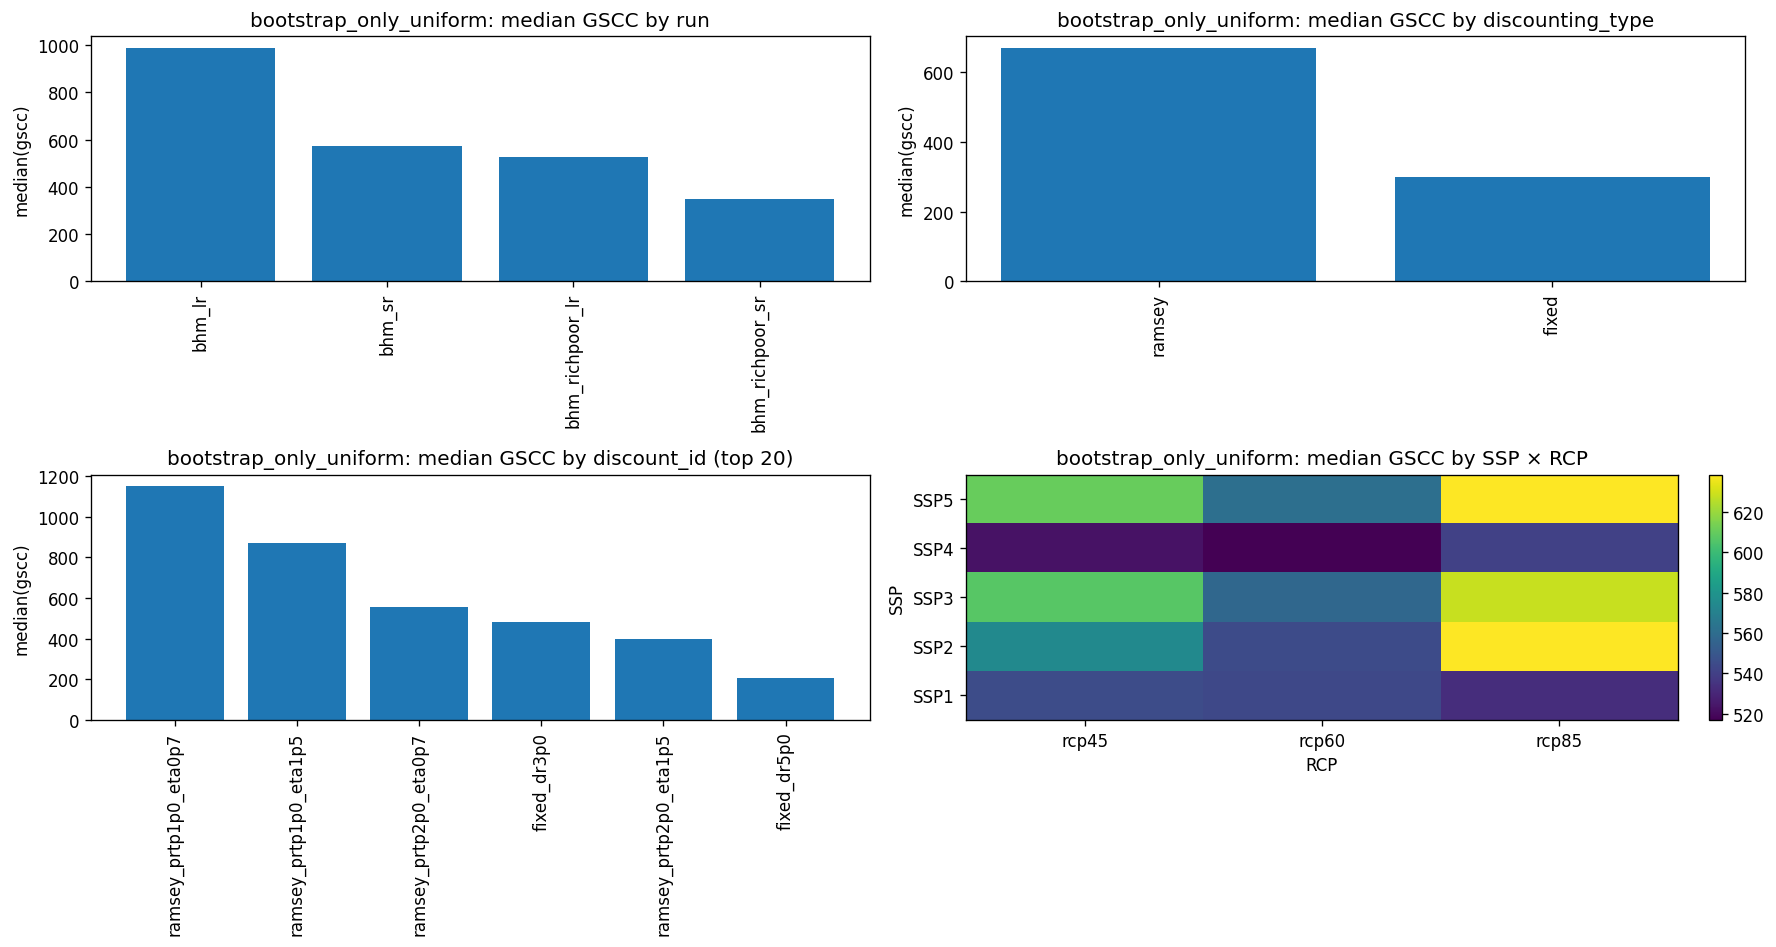

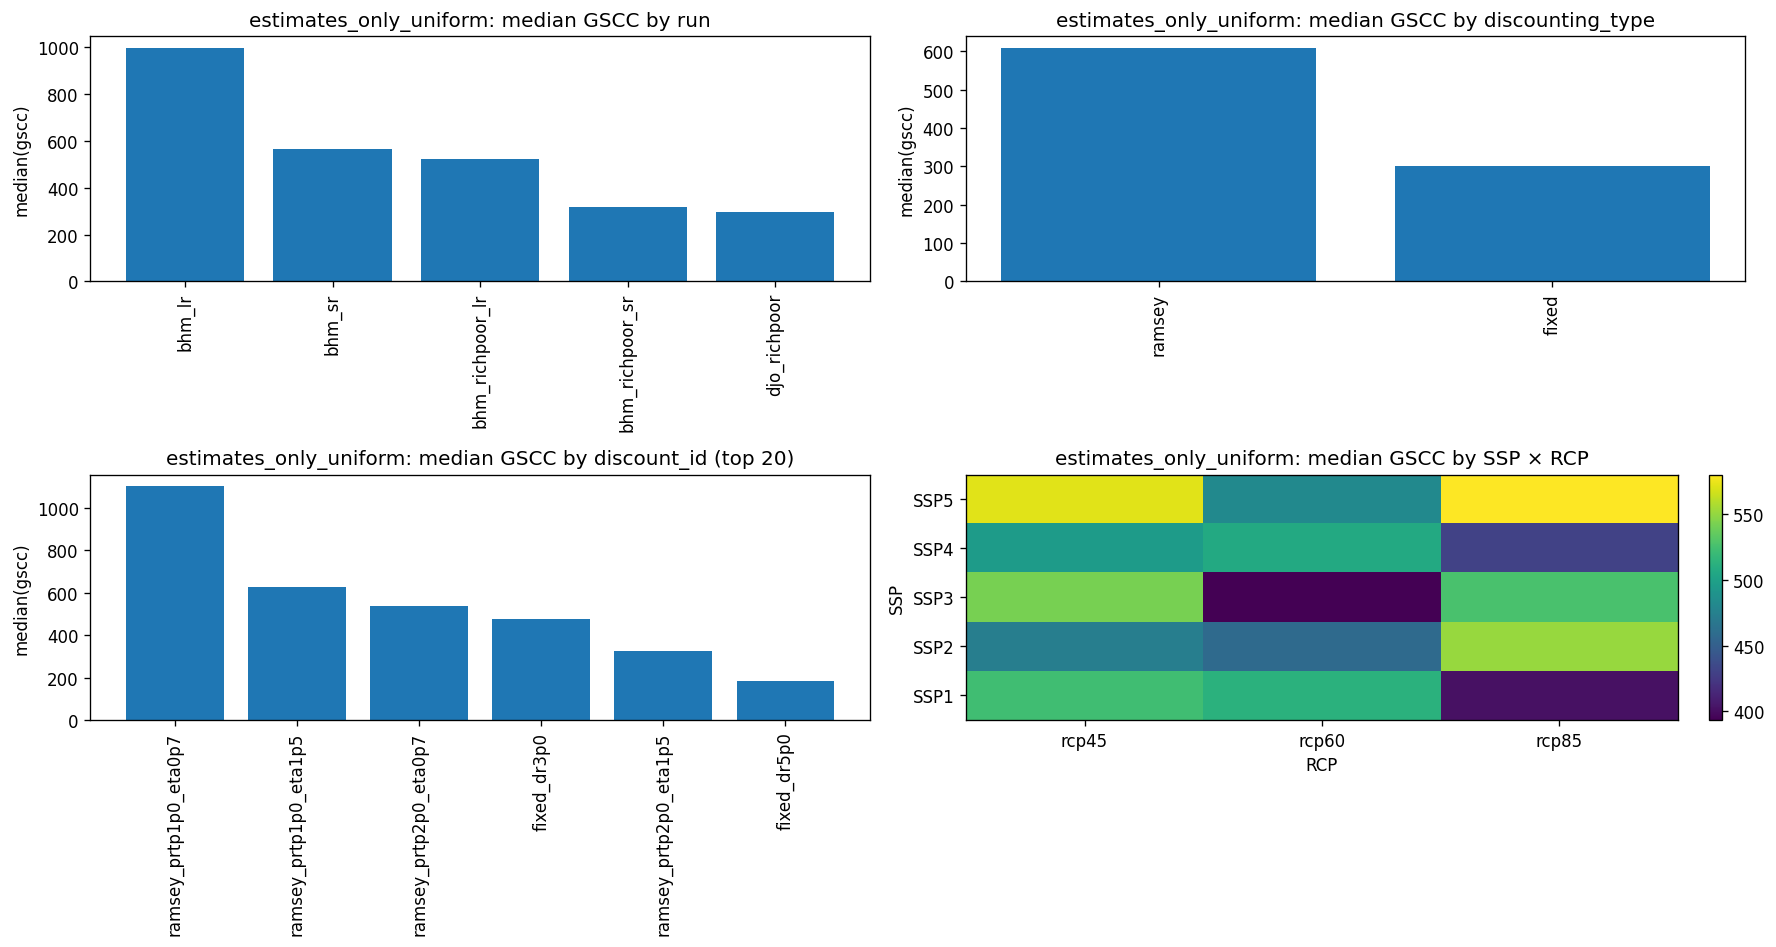

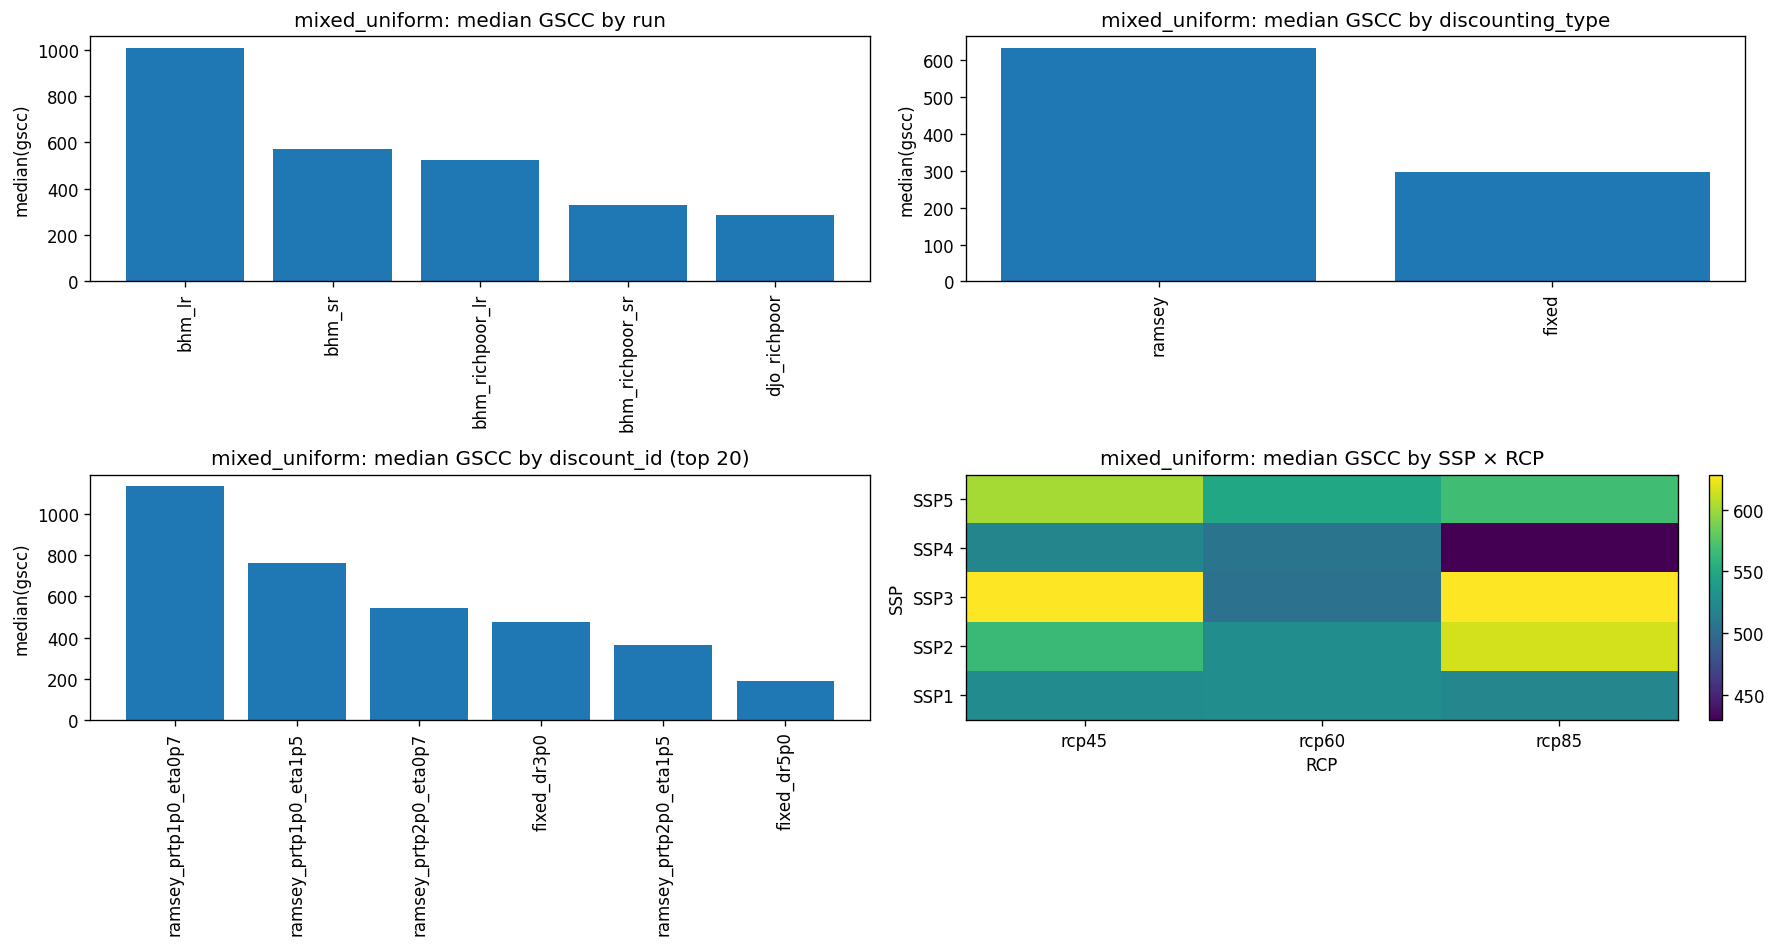

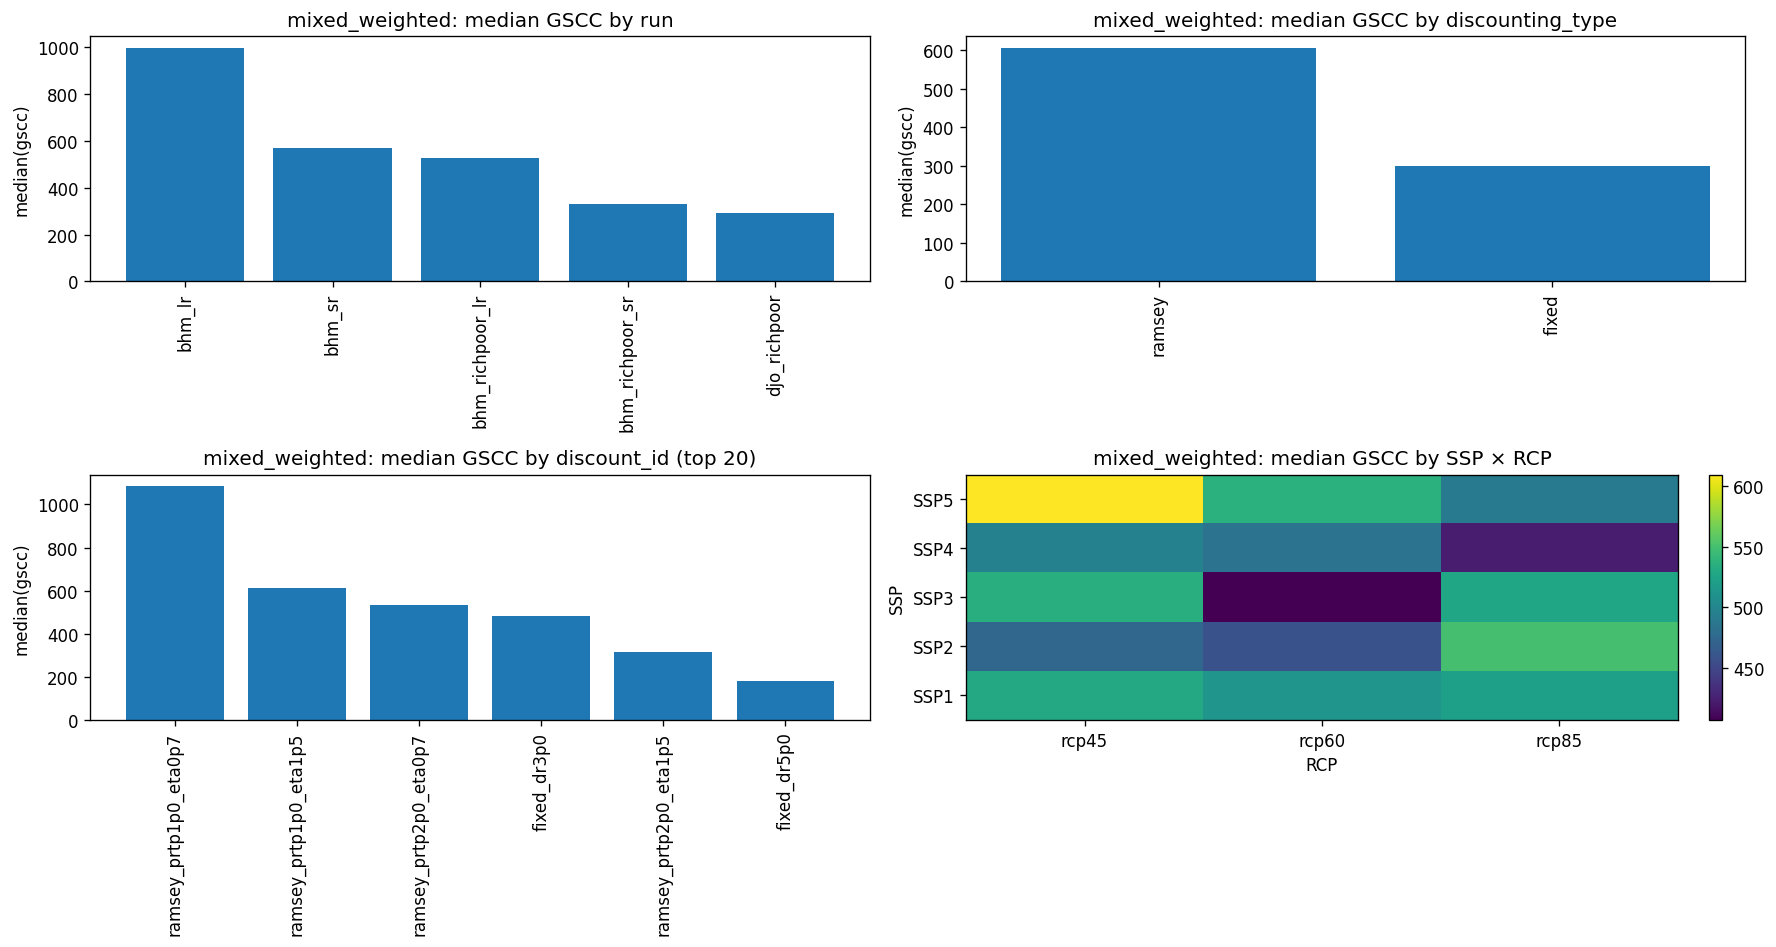

In [7]:
for name, out in variants.items():
    df = out.draws_df
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    p.bar_median_by(axes[0, 0], df, group_col="run",
                    value_col="gscc", title=f"{name}: median GSCC by run")
    p.bar_median_by(axes[0, 1], df, group_col="discounting_type",
                    value_col="gscc", title=f"{name}: median GSCC by discounting_type")
    p.bar_median_by(axes[1, 0], df, group_col="discount_id",
                    value_col="gscc", top_k=20,
                    title=f"{name}: median GSCC by discount_id (top 20)")
    p.heatmap_median_ssp_rcp(axes[1, 1], df, value_col="gscc",
                             title=f"{name}: median GSCC by SSP × RCP")
    plt.tight_layout()
    plt.show()

In [8]:
# Variance decomposition baseline: R² of predicting log_gscc from labels
lam_baseline = 10.0
r2_rows = []
for name, out in variants.items():
    fit = fit_ridge_decomposition(
        out.scenarios_df, factors, lam_baseline, target_col="log_gscc"
    )
    r2_rows.append({
        "variant": name,
        "lam": lam_baseline,
        "r2_raw": round(float(fit["r2"]), 3),
        "structured_var_share": round(float(fit["structured_var_share"]), 3),
        "n_scenarios": int(len(out.scenarios_df)),
    })
pd.DataFrame(r2_rows)

,variant,lam,r2_raw,structured_var_share,n_scenarios
0,bootstrap_only_uniform,10.0,0.493,0.644,696
1,estimates_only_uniform,10.0,0.306,0.618,762
2,mixed_uniform,10.0,0.303,0.692,1458
3,mixed_weighted,10.0,0.303,0.692,1458


## **Section 3. Ridge decomposition**

For each variant:

1. Run **lambda stability** analysis across the grid (fit on scenario table, apply to draws).
2. Select λ\* by **max R² drop** — the penalty that maximally separates raw and adjusted label-dependence.
3. Apply decomposition to all B draws: `log_adj = log_raw − centered_systematic`.
4. Plot raw vs. adjusted distribution overlays.

bootstrap_only_uniform  λ*=10.0  R²_raw=0.493  structured_share=0.644


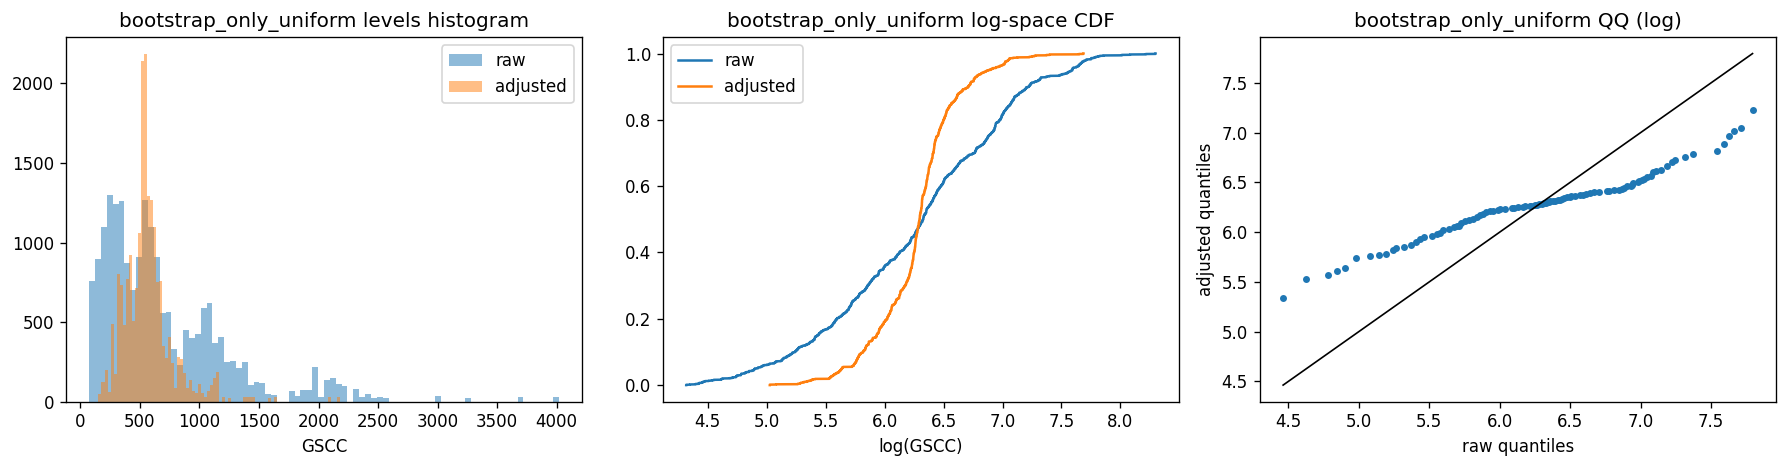

estimates_only_uniform  λ*=10.0  R²_raw=0.306  structured_share=0.618


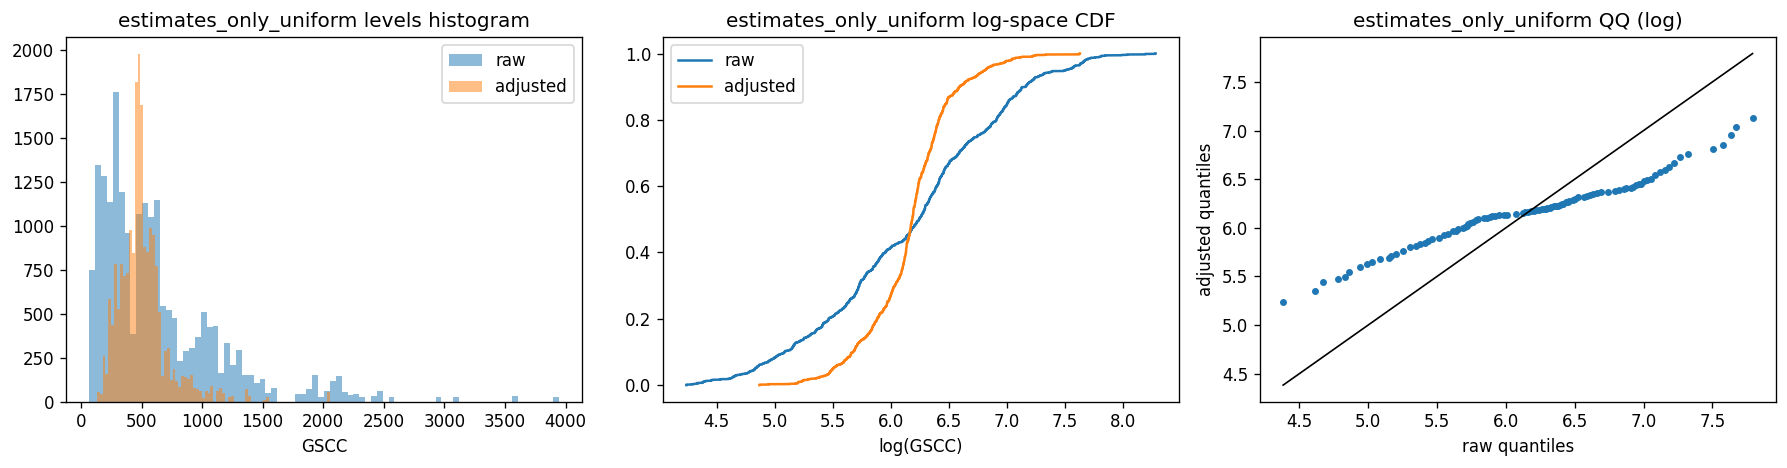

mixed_uniform  λ*=100.0  R²_raw=0.526  structured_share=0.336


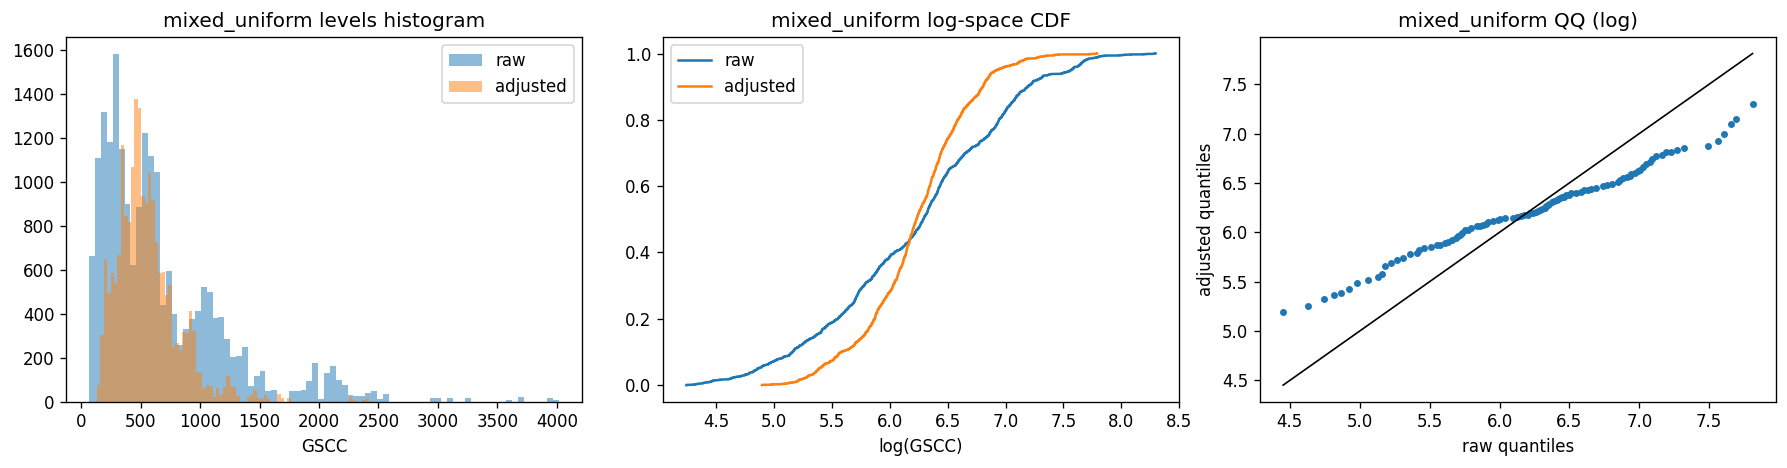

mixed_weighted  λ*=100.0  R²_raw=0.526  structured_share=0.336


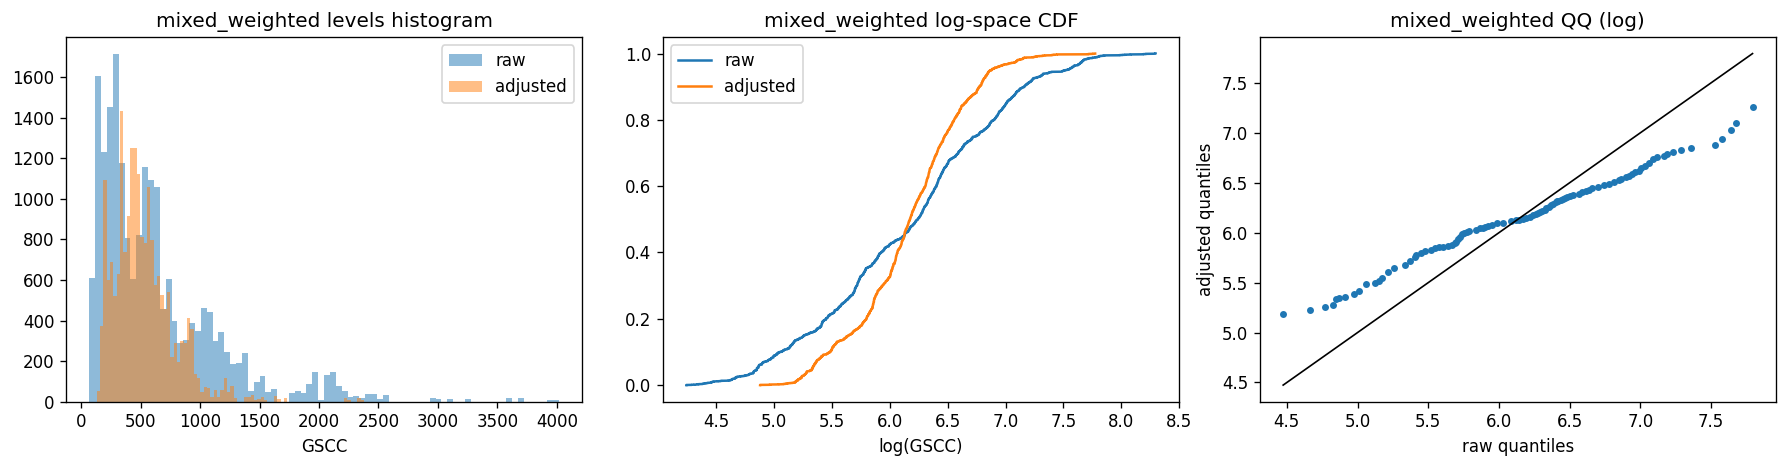

In [9]:
decomp_results: dict = {}
lambda_star: dict = {}

def _subsample(df: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    if int(n) >= len(df):
        return df
    return df.sample(n=int(n), random_state=int(seed)).reset_index(drop=True)

for name, out in variants.items():
    apply_stab = _subsample(out.draws_df, B_robust, seed)
    stab = lambda_stability_analysis(
        out.scenarios_df,
        apply_df=apply_stab,
        factors=factors,
        lambda_grid=lambda_grid,
    )
    lam_star = select_lambda_star(stab)
    lambda_star[name] = lam_star

    fit = fit_ridge_decomposition(out.scenarios_df, factors, lam_star, target_col="log_gscc")
    df_adj = apply_decomposition(fit, out.draws_df)
    decomp_results[name] = {"fit": fit, "df_adj": df_adj, "stability": stab}

    print(
        f"{name}  λ*={lam_star}  "
        f"R²_raw={fit['r2']:.3f}  "
        f"structured_share={fit['structured_var_share']:.3f}"
    )
    p.plot_raw_vs_adjusted_distributions(df_adj, title_prefix=name)
    plt.show()

## **Section 4. Formal property checks**

Key invariants verified per variant:

- **Centering**: `mean(systematic_centered) ≈ 0` (by construction)
- **Mean preservation**: `mean(log_raw) ≈ mean(log_adj)` (centering shifts no mass on the mean)
- **R² drop**: label-dependence collapses from `r2_raw` to `r2_adj` after adjustment

In [10]:
rows = []
for name, res in decomp_results.items():
    fit = res["fit"]
    df_adj = res["df_adj"]
    out = variants[name]

    mean_sys   = float(np.mean(df_adj["systematic_centered"].to_numpy(dtype=float)))
    mean_log_r = float(np.mean(df_adj["log_gscc"].to_numpy(dtype=float)))
    mean_log_a = float(np.mean(df_adj["log_gscc_adj"].to_numpy(dtype=float)))

    scen_adj = apply_decomposition(fit, out.scenarios_df)
    fit_adj  = fit_ridge_decomposition(
        scen_adj, factors, lambda_star[name], target_col="log_gscc_adj"
    )
    rows.append({
        "variant":                   name,
        "lambda_star":               float(lambda_star[name]),
        "mean_systematic_centered":  round(mean_sys,   8),
        "mean_log_raw":              round(mean_log_r, 4),
        "mean_log_adj":              round(mean_log_a, 4),
        "r2_raw":                    round(float(fit["r2"]),      3),
        "r2_adj":                    round(float(fit_adj["r2"]),  3),
        "r2_drop":                   round(float(fit["r2"] - fit_adj["r2"]), 3),
        "structured_var_share":      round(float(fit["structured_var_share"]), 3),
        "residual_var_share":        round(float(fit["residual_var_share"]),   3),
    })

pd.DataFrame(rows)

,variant,lambda_star,mean_systematic_centered,mean_log_raw,mean_log_adj,r2_raw,r2_adj,r2_drop,structured_var_share,residual_var_share
0,bootstrap_only_uniform,10.0,0.0,6.2783,6.2783,0.493,0.018,0.475,0.644,0.209
1,estimates_only_uniform,10.0,-0.0,6.1687,6.1687,0.306,-0.043,0.349,0.618,0.230
2,mixed_uniform,100.0,-0.0,6.2244,6.2244,0.526,0.173,0.353,0.336,0.337
3,mixed_weighted,100.0,-0.0,6.1625,6.1625,0.526,0.173,0.353,0.336,0.337


## **Section 5. Robustness: lambda stability**

Lambda stability curves show how R² (raw and adjusted) and distribution summaries evolve across the penalty grid. Effect-vector correlations between neighbouring λ values confirm that the selected penalty is not on a sensitivity cliff.

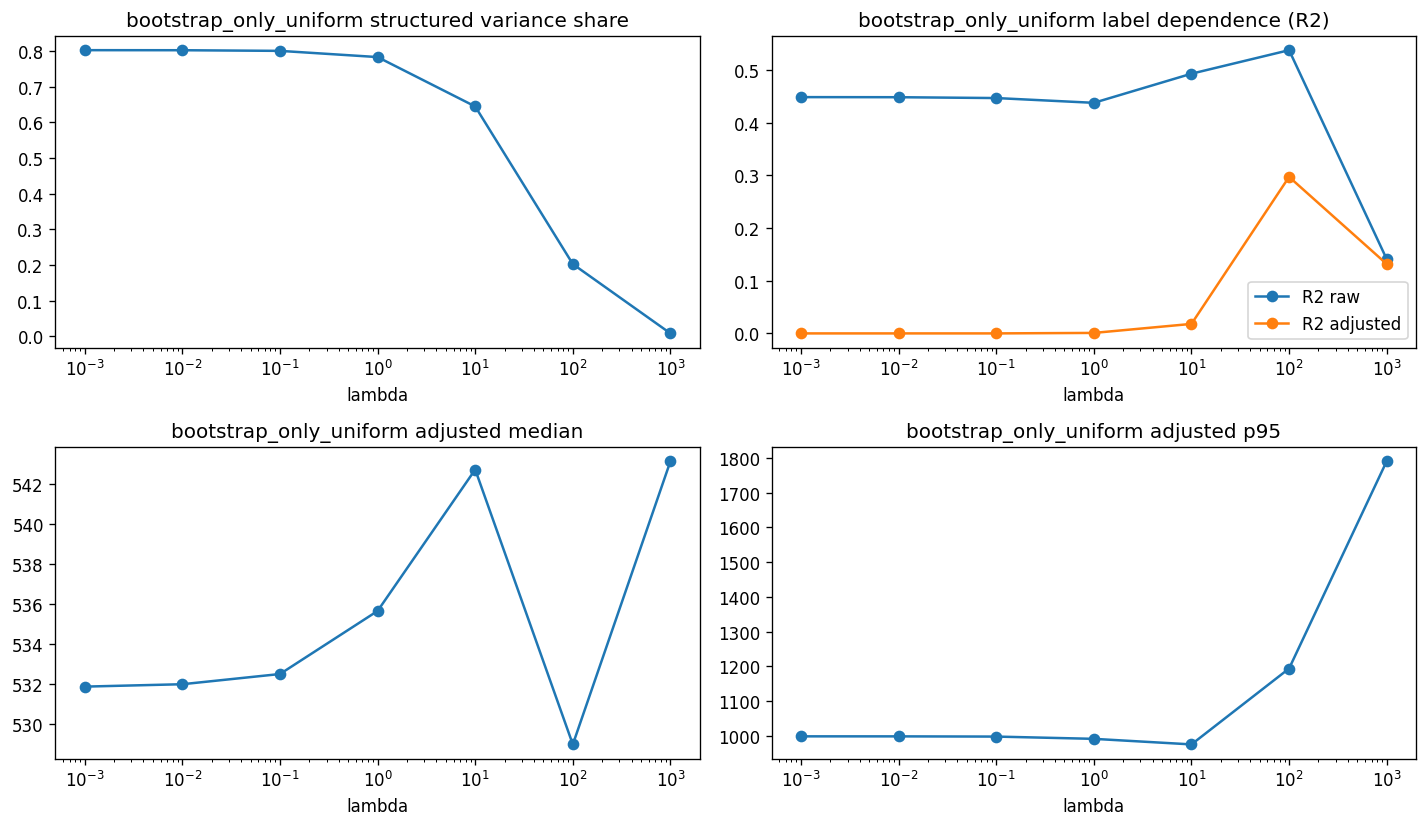

bootstrap_only_uniform  discount_id effect corr  λ*=10.0 vs λ=1.0  → 1.0
bootstrap_only_uniform  discount_id effect corr  λ*=10.0 vs λ=100.0  → 0.999


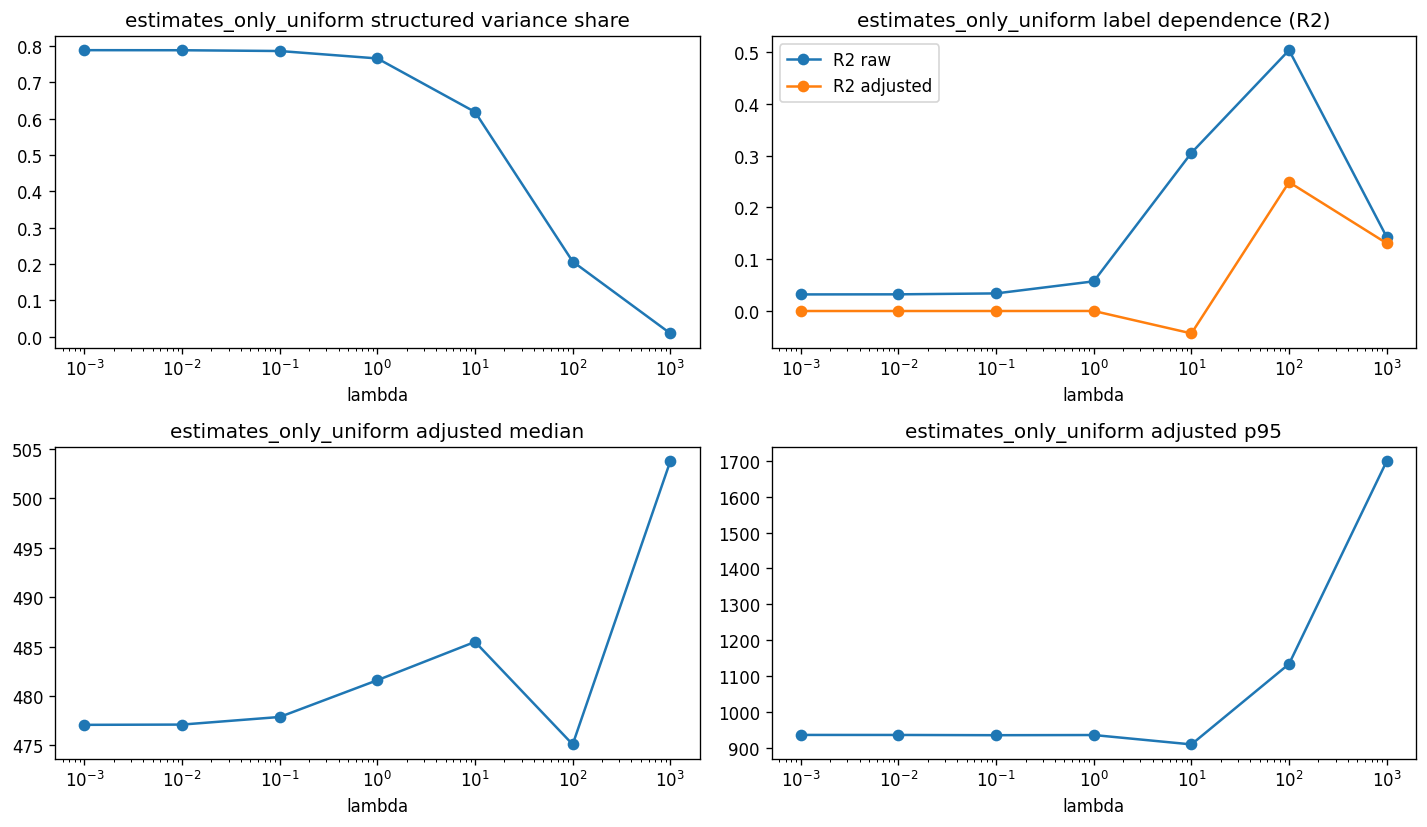

estimates_only_uniform  discount_id effect corr  λ*=10.0 vs λ=1.0  → 1.0
estimates_only_uniform  discount_id effect corr  λ*=10.0 vs λ=100.0  → 1.0


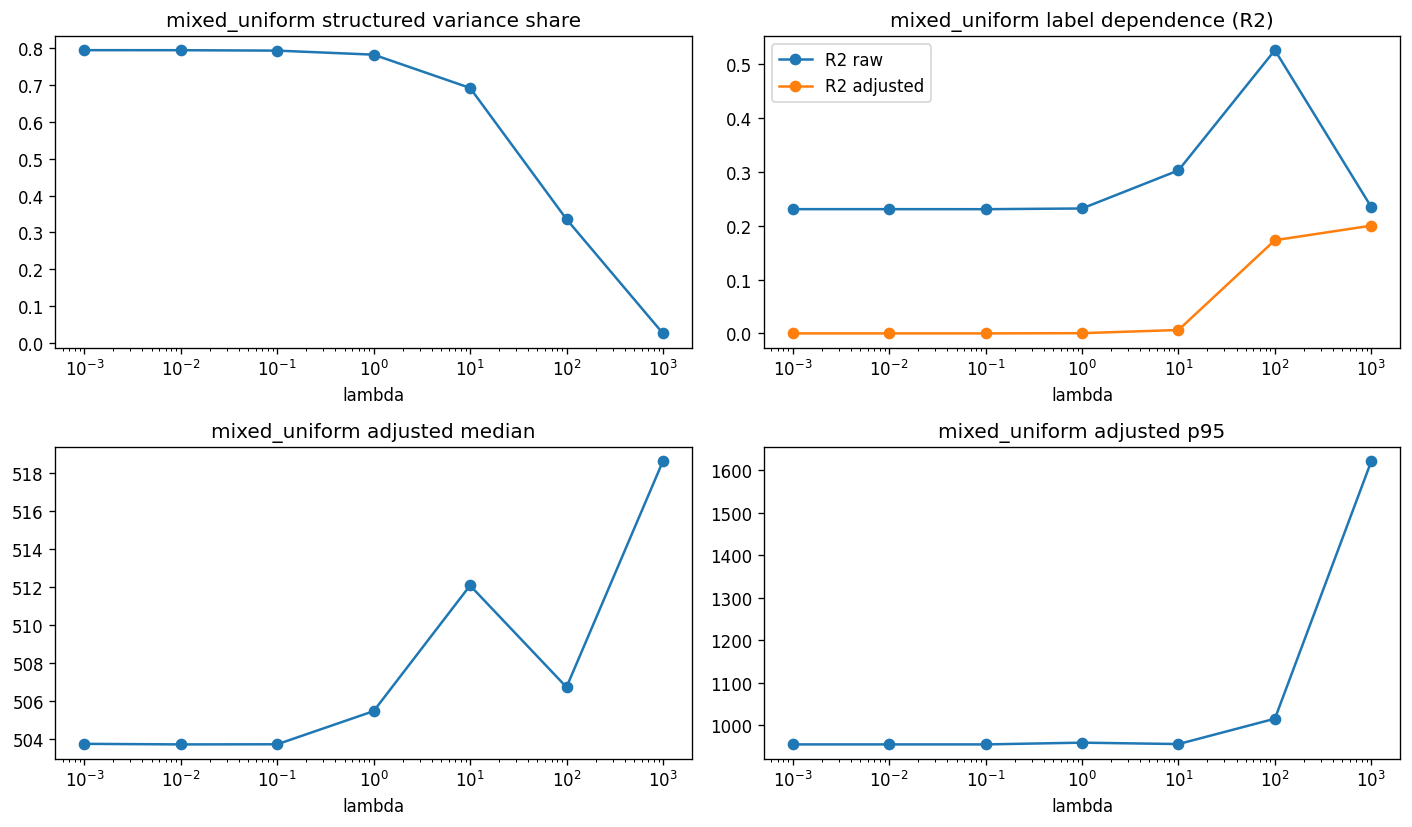

mixed_uniform  discount_id effect corr  λ*=100.0 vs λ=10.0  → 1.0
mixed_uniform  discount_id effect corr  λ*=100.0 vs λ=1000.0  → 1.0


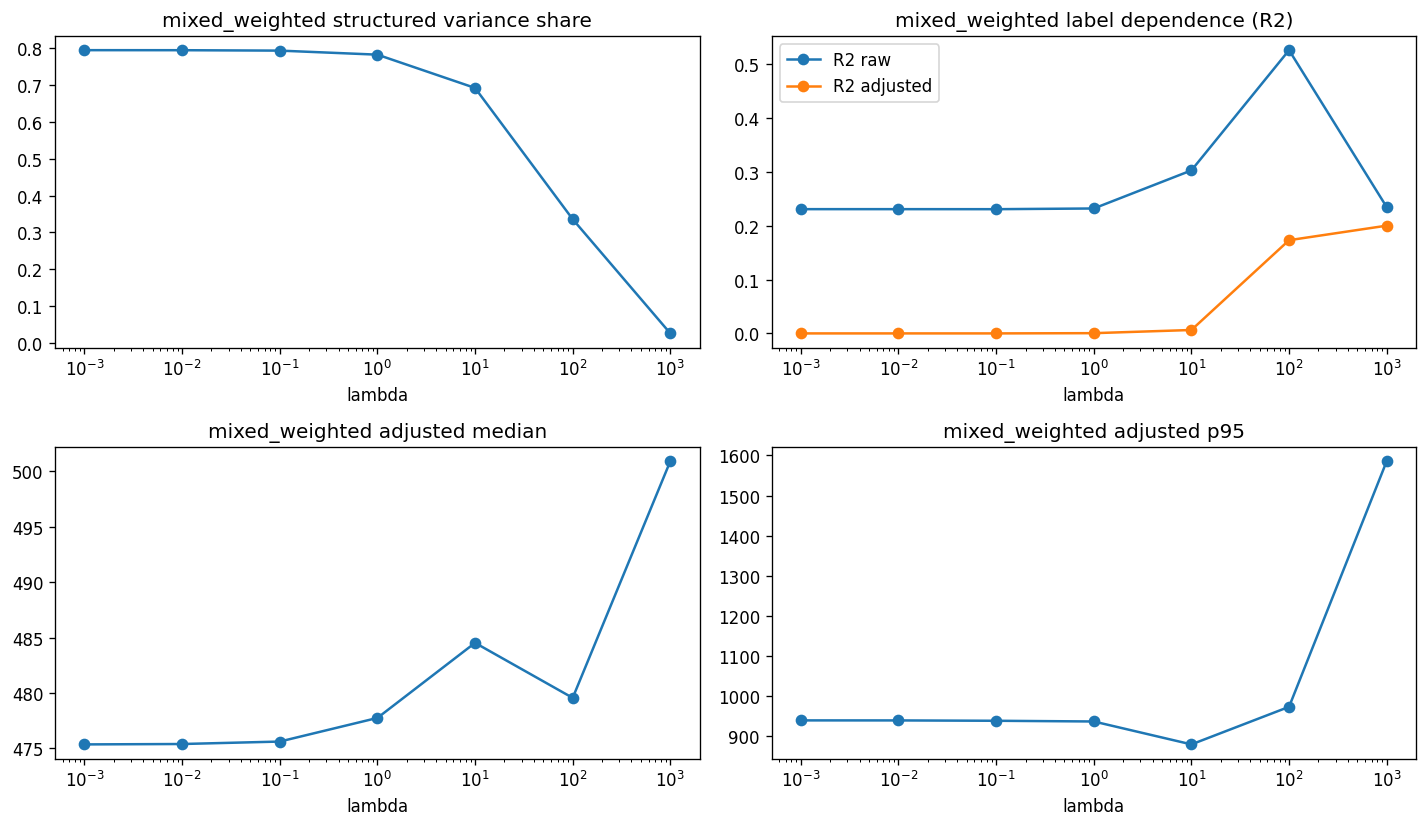

mixed_weighted  discount_id effect corr  λ*=100.0 vs λ=10.0  → 1.0
mixed_weighted  discount_id effect corr  λ*=100.0 vs λ=1000.0  → 1.0


In [11]:
for name, res in decomp_results.items():
    stab = res["stability"]
    p.plot_lambda_stability(stab, title_prefix=name)
    plt.show()

    lam_star_val = float(lambda_star[name])
    lam_vals     = [float(x) for x in stab["lam"].tolist()]
    if lam_star_val in lam_vals:
        i_star    = lam_vals.index(lam_star_val)
        neighbors = []
        if i_star - 1 >= 0:              
            neighbors.append(lam_vals[i_star - 1])
        if i_star + 1 < len(lam_vals):   
            neighbors.append(lam_vals[i_star + 1])

        fit_star = fit_ridge_decomposition(
            variants[name].scenarios_df, factors, lam_star_val, target_col="log_gscc"
        )
        for lam_nb in neighbors:
            fit_nb = fit_ridge_decomposition(
                variants[name].scenarios_df, factors, float(lam_nb), target_col="log_gscc"
            )
            corr = effect_vector_correlation(fit_star, fit_nb, factor="discount_id")
            print(
                f"{name}  discount_id effect corr  "
                f"λ*={lam_star_val} vs λ={lam_nb}  → "
                f"{round(float(corr), 3) if np.isfinite(corr) else corr}"
            )

## **Section 6. Leave-one-spec-out influence (raw distribution)**

For each factor group (run, discount_id, climate), remove one level at a time, re-draw B samples, and report the percentage change in p95 relative to the full-data baseline.

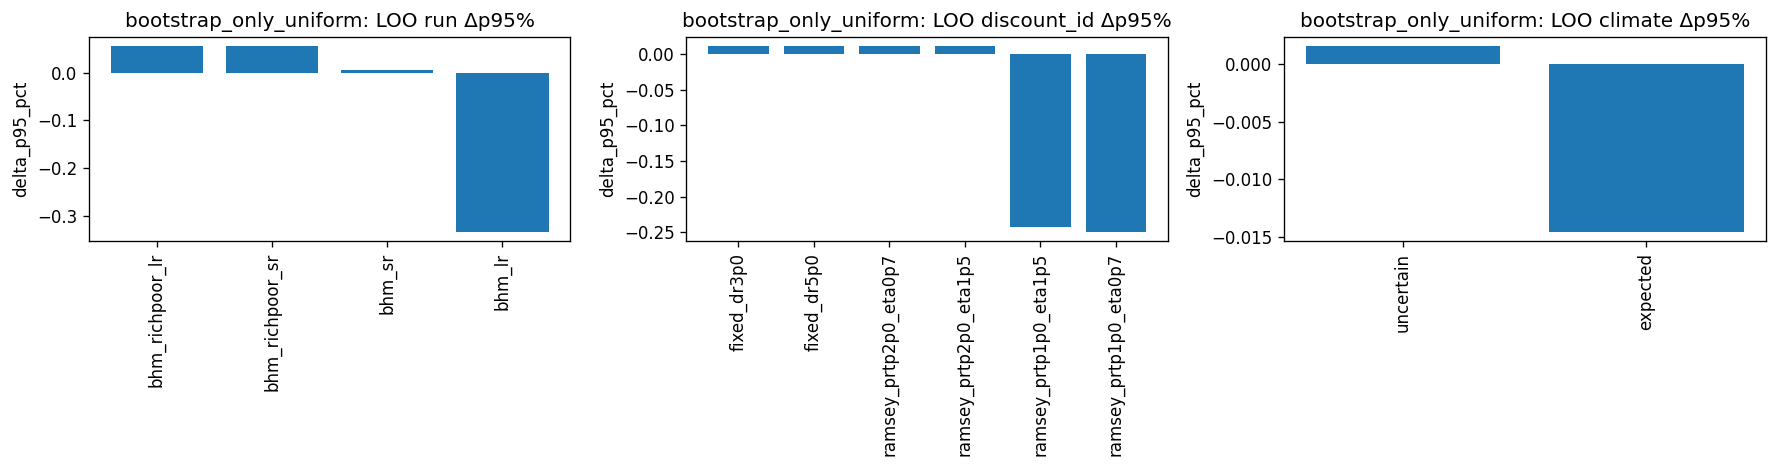

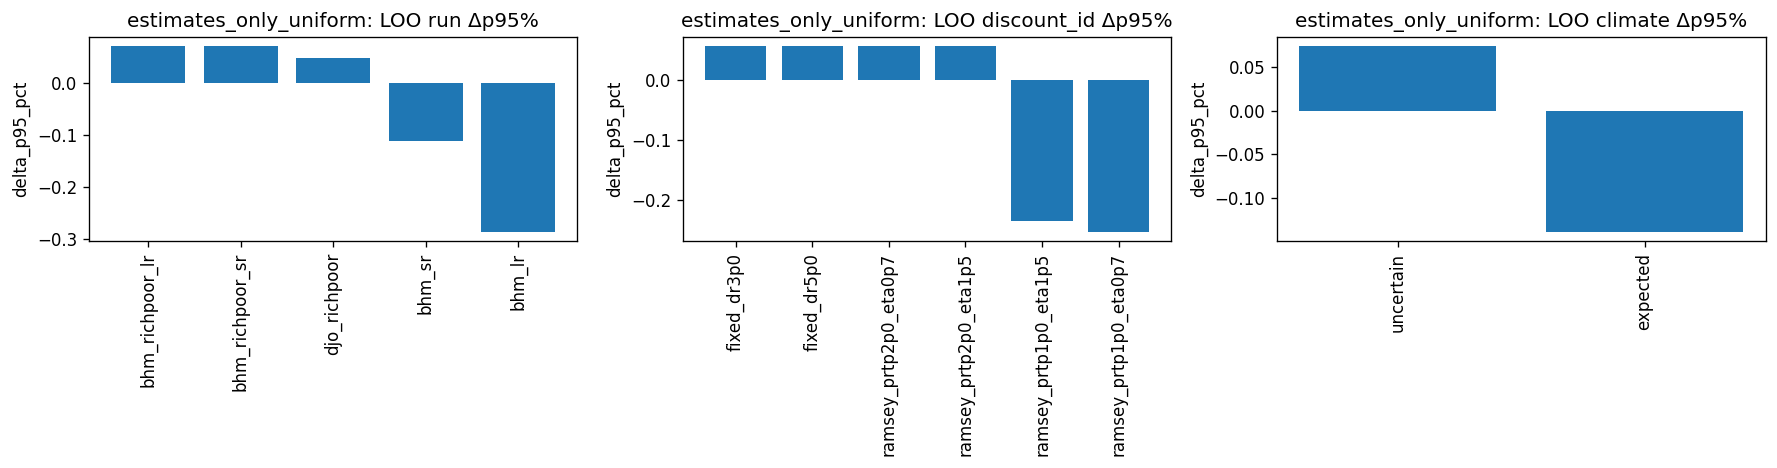

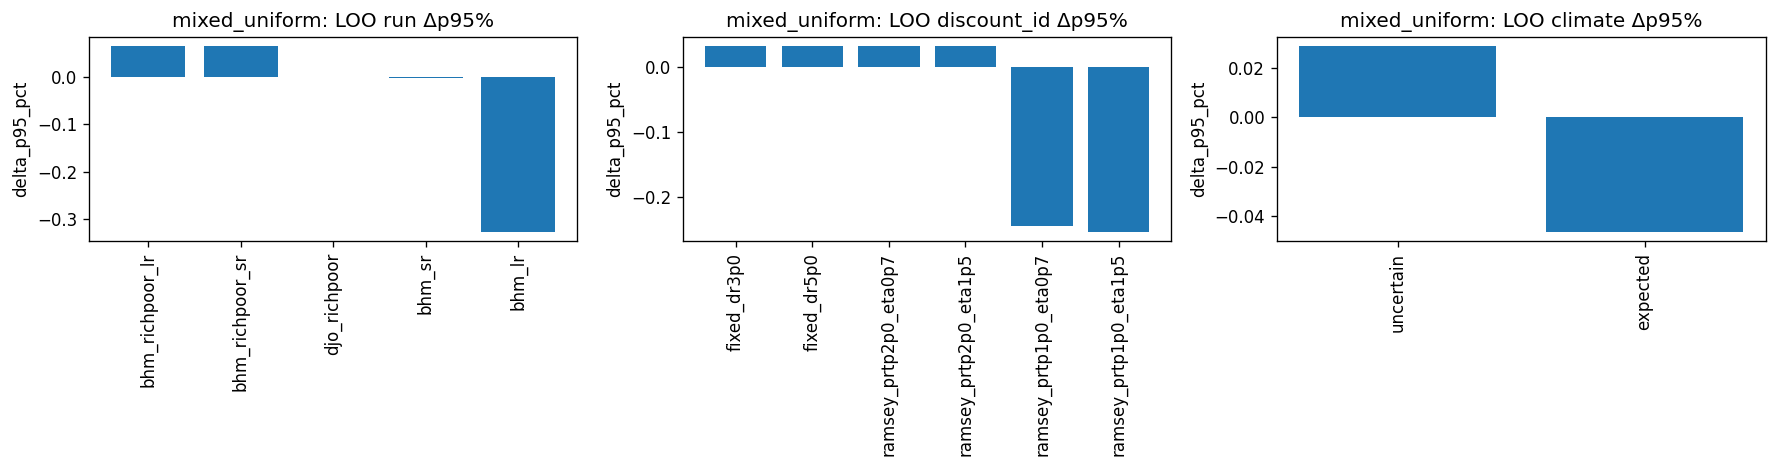

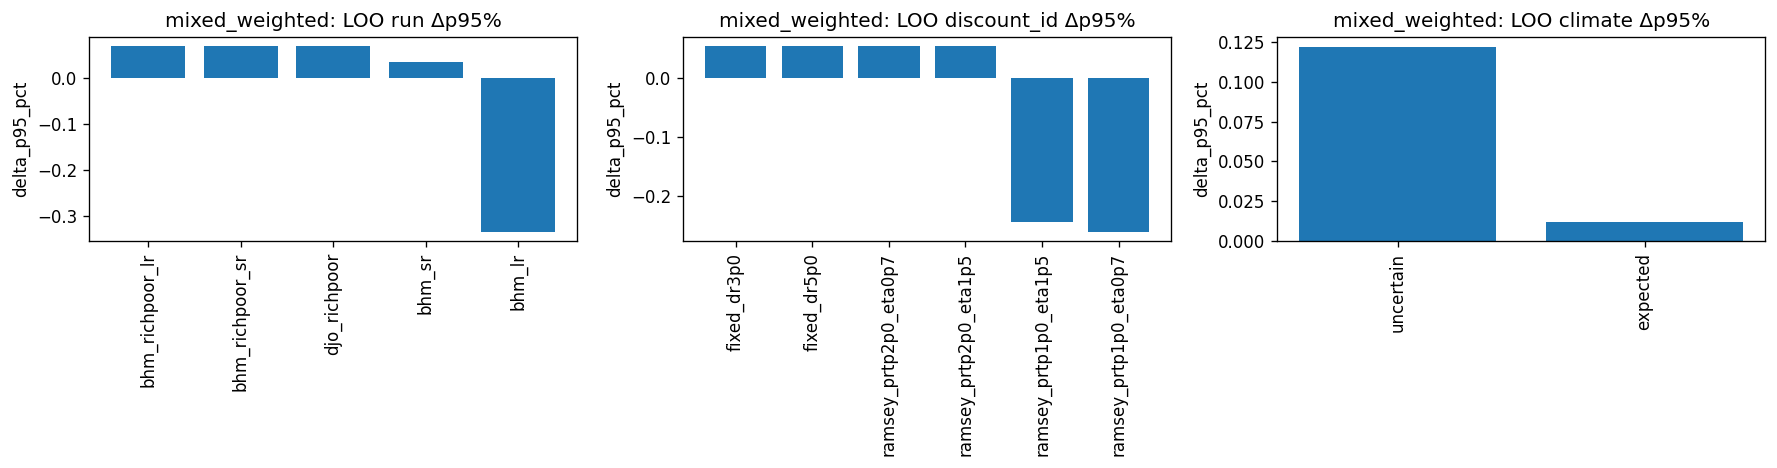

In [12]:
for name, out in variants.items():
    scen   = out.scenarios_df
    scheme = variant_specs[name].sampling_scheme

    infl_run  = leave_one_spec_out_influence(
        scen, sampling_scheme=scheme, B=B_influence, seed=seed, group_col="run"
    )
    infl_disc = leave_one_spec_out_influence(
        scen, sampling_scheme=scheme, B=B_influence, seed=seed, group_col="discount_id"
    )
    infl_clim = leave_one_spec_out_influence(
        scen, sampling_scheme=scheme, B=B_influence, seed=seed, group_col="climate"
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    p.influence_bars(axes[0], infl_run,  metric="delta_p95_pct",
                     title=f"{name}: LOO run Δp95%")
    p.influence_bars(axes[1], infl_disc, metric="delta_p95_pct",
                     title=f"{name}: LOO discount_id Δp95%")
    p.influence_bars(axes[2], infl_clim, metric="delta_p95_pct",
                     title=f"{name}: LOO climate Δp95%")
    plt.tight_layout()
    plt.show()

## **Section 7. Leave-one-spec-out influence (adjusted distribution)**

Same leave-one-out design, but now **re-fitting the decomposition** on the reduced scenario table at the same λ\* and measuring deltas on `gscc_adj`. This tests whether label-structured removal still shifts the adjusted distribution.

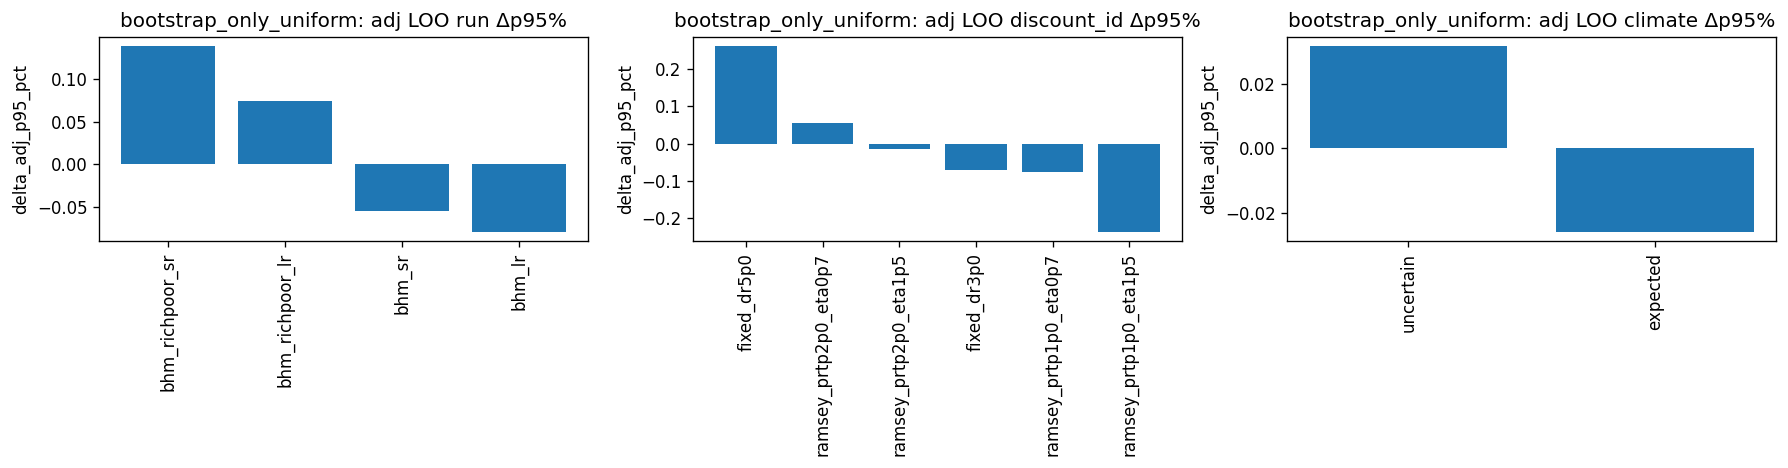

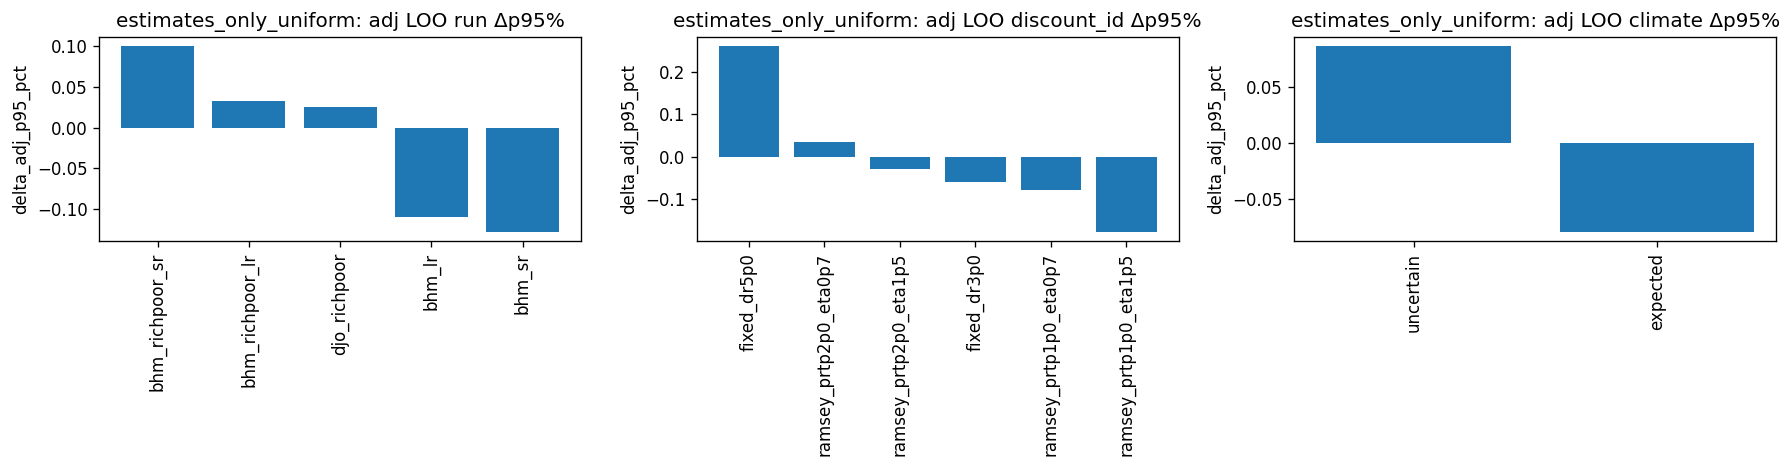

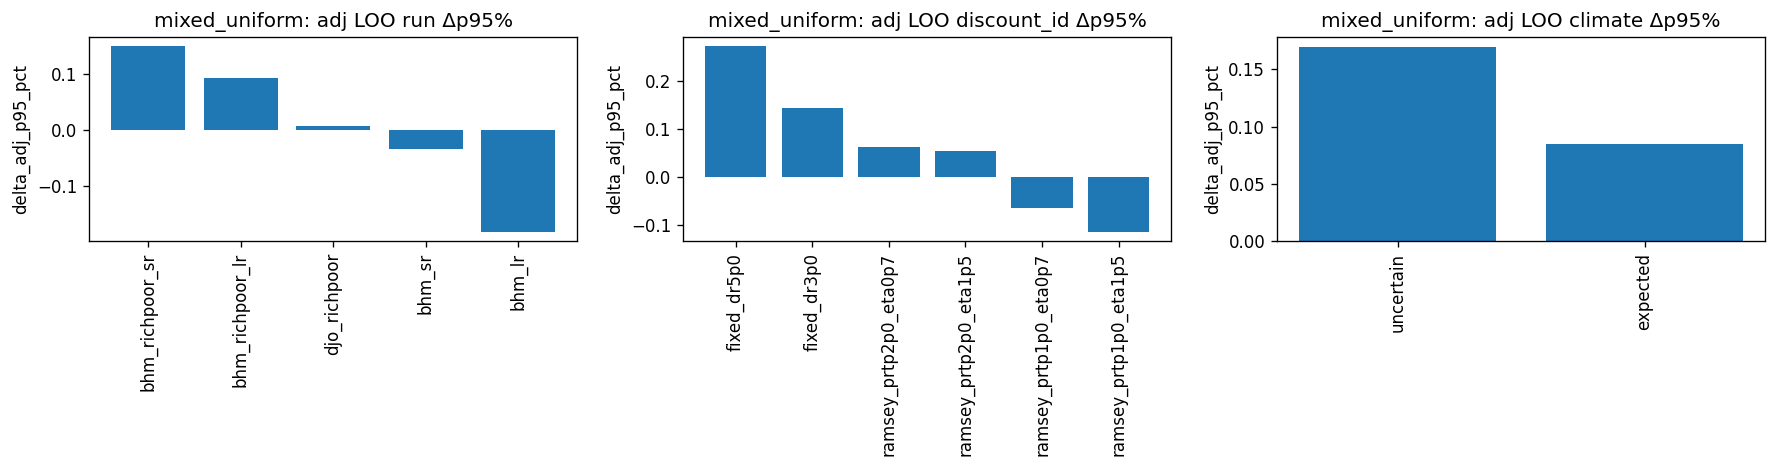

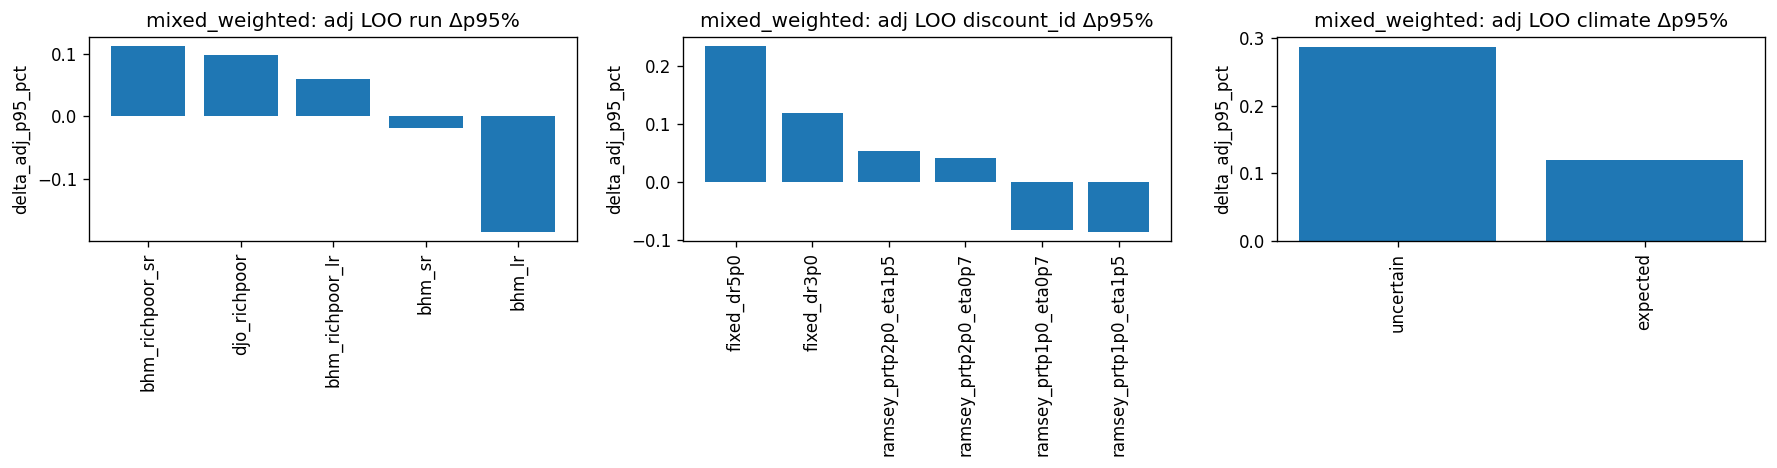

In [13]:
def _topk_by_count(scen: pd.DataFrame, col: str, k: int) -> list:
    return scen[col].astype(str).value_counts().head(int(k)).index.astype(str).tolist()

adj_influence_results: dict = {}

for name, out in variants.items():
    scheme      = variant_specs[name].sampling_scheme
    scen_full   = out.scenarios_df
    df_adj_full = decomp_results[name]["df_adj"]
    base        = summarize_draws(df_adj_full["gscc_adj"].to_numpy(dtype=float))

    group_dfs: dict = {}
    for group_col in ["run", "discount_id", "climate"]:
        if group_col not in scen_full.columns:
            continue
        levels = sorted(pd.unique(scen_full[group_col].astype(str)))
        if group_col == "discount_id":
            levels = _topk_by_count(scen_full, group_col, k=20)

        rows = []
        for lev in levels:
            sub_scen = scen_full[scen_full[group_col].astype(str) != str(lev)].copy()
            if sub_scen.empty:
                continue
            _draws, _idx, sub_draws_df = draw_distribution(
                sub_scen, B=B_influence, seed=seed, sampling_scheme=scheme
            )
            lam     = float(lambda_star[name])
            fit_sub = fit_ridge_decomposition(sub_scen, factors, lam, target_col="log_gscc")
            sub_adj = apply_decomposition(fit_sub, sub_draws_df)
            s       = summarize_draws(sub_adj["gscc_adj"].to_numpy(dtype=float))
            rows.append({
                "group_col":            group_col,
                "left_out":             str(lev),
                "n_scenarios":          int(len(sub_scen)),
                "delta_adj_mean_pct":   float((s["mean"]   - base["mean"])   / base["mean"])   if base["mean"]   != 0 else float("nan"),
                "delta_adj_median_pct": float((s["median"] - base["median"]) / base["median"]) if base["median"] != 0 else float("nan"),
                "delta_adj_p95_pct":    float((s["p95"]    - base["p95"])    / base["p95"])    if base["p95"]    != 0 else float("nan"),
            })

        df_inf = pd.DataFrame(rows)
        if not df_inf.empty:
            df_inf = df_inf.sort_values("delta_adj_p95_pct", ascending=False).reset_index(drop=True)
        group_dfs[group_col] = df_inf

    adj_influence_results[name] = group_dfs

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    p.influence_bars(axes[0], group_dfs.get("run",         pd.DataFrame()),
                     metric="delta_adj_p95_pct", title=f"{name}: adj LOO run Δp95%")
    p.influence_bars(axes[1], group_dfs.get("discount_id", pd.DataFrame()),
                     metric="delta_adj_p95_pct", title=f"{name}: adj LOO discount_id Δp95%")
    p.influence_bars(axes[2], group_dfs.get("climate",     pd.DataFrame()),
                     metric="delta_adj_p95_pct", title=f"{name}: adj LOO climate Δp95%")
    plt.tight_layout()
    plt.show()

In [14]:
# Top-10 adjusted influences by |Δp95%| across all variants and groups
rows = []
for variant_name, groups in adj_influence_results.items():
    for group_col, df_inf in groups.items():
        if df_inf is None or df_inf.empty:
            continue
        tmp = df_inf.copy()
        tmp["abs_delta"] = tmp["delta_adj_p95_pct"].abs()
        for _, r in tmp.sort_values("abs_delta", ascending=False).head(10).iterrows():
            rows.append({
                "variant":              variant_name,
                "group_col":            group_col,
                "left_out":             r["left_out"],
                "n_scenarios":          int(r["n_scenarios"]),
                "delta_adj_p95_pct":    round(float(r["delta_adj_p95_pct"]),   4),
                "delta_adj_median_pct": round(float(r["delta_adj_median_pct"]), 4),
                "delta_adj_mean_pct":   round(float(r["delta_adj_mean_pct"]),   4),
            })

top10_adj = pd.DataFrame(rows)
top10_adj.sort_values(
    ["variant", "group_col", "delta_adj_p95_pct"],
    ascending=[True, True, False]
)

,variant,group_col,left_out,n_scenarios,delta_adj_p95_pct,delta_adj_median_pct,delta_adj_mean_pct
10,bootstrap_only_uniform,climate,uncertain,336,0.0318,0.0258,0.0195
11,bootstrap_only_uniform,climate,expected,360,-0.0260,0.0008,-0.0040
4,bootstrap_only_uniform,discount_id,fixed_dr5p0,580,0.2611,0.2089,0.2125
8,bootstrap_only_uniform,discount_id,ramsey_prtp2p0_eta0p7,580,0.0546,-0.0037,-0.0071
9,bootstrap_only_uniform,discount_id,ramsey_prtp2p0_eta1p5,580,-0.0139,0.0582,0.0463
7,bootstrap_only_uniform,discount_id,fixed_dr3p0,580,-0.0714,0.0410,0.0109
6,bootstrap_only_uniform,discount_id,ramsey_prtp1p0_eta0p7,580,-0.0752,-0.1612,-0.1397
5,bootstrap_only_uniform,discount_id,ramsey_prtp1p0_eta1p5,580,-0.2355,-0.0946,-0.1062
0,bootstrap_only_uniform,run,bhm_richpoor_sr,516,0.1390,0.2117,0.2079
2,bootstrap_only_uniform,run,bhm_richpoor_lr,516,0.0742,0.0510,0.0412


## **Section 8. Family exclusion & sampling comparison**

**Family exclusion**: refit the decomposition omitting one entire factor family at a time (run, scenario_id, dmgfuncpar) to measure each family's contribution to structured variance.

**Cross-variant comparison**: raw vs. adjusted summary stats and R² drop side by side for all four variants.

In [15]:
# ── Family exclusion ───────────────────────────────────────────────────────
exclude_families = ["run", "scenario_id", "dmgfuncpar"]
for name, out in variants.items():
    lam     = float(lambda_star[name])
    df_excl = family_exclusion_analysis(
        out.scenarios_df,
        apply_df=out.draws_df,
        factors=factors,
        lam=lam,
        exclude=exclude_families,
    )
    print(f"\n{name} — family exclusion:")
    display(df_excl)

# ── Cross-variant summary (raw vs adjusted) ───────────────────────────────
comp_rows = []
for name, out in variants.items():
    df_adj = decomp_results[name]["df_adj"]
    fit    = decomp_results[name]["fit"]

    raw = summarize_draws(out.draws)
    adj = summarize_draws(df_adj["gscc_adj"].to_numpy(dtype=float))

    scen_adj = apply_decomposition(fit, out.scenarios_df)
    fit_adj  = fit_ridge_decomposition(
        scen_adj, factors, lambda_star[name], target_col="log_gscc_adj"
    )
    comp_rows.append({
        "variant":              name,
        "raw_mean":             round(raw["mean"],   1),
        "raw_median":           round(raw["median"], 1),
        "raw_p95":              round(raw["p95"],    1),
        "adj_mean":             round(adj["mean"],   1),
        "adj_median":           round(adj["median"], 1),
        "adj_p95":              round(adj["p95"],    1),
        "structured_var_share": round(float(fit["structured_var_share"]), 3),
        "r2_raw":               round(float(fit["r2"]),      3),
        "r2_adj":               round(float(fit_adj["r2"]),  3),
        "r2_drop":              round(float(fit["r2"] - fit_adj["r2"]), 3),
    })

pd.DataFrame(comp_rows)


bootstrap_only_uniform — family exclusion:


,excluded,r2_raw,r2_adj,r2_drop,structured_var_share,adj_mean,adj_median,adj_p95
0,none,0.492993,0.018037,0.474955,0.644423,567.741962,542.734454,975.307288
1,run,0.541243,0.005245,0.535998,0.467282,607.140874,530.830378,1195.968046
2,scenario_id,0.461586,0.002087,0.459499,0.639460,569.877689,535.146440,1018.223333
3,dmgfuncpar,0.492993,0.018037,0.474955,0.644423,567.741962,542.734454,975.307288



estimates_only_uniform — family exclusion:


,excluded,r2_raw,r2_adj,r2_drop,structured_var_share,adj_mean,adj_median,adj_p95
0,none,0.305564,-0.043271,0.348835,0.618280,512.948801,485.469674,908.717040
1,run,0.505239,0.006403,0.498837,0.443890,553.089071,484.273138,1109.505234
2,scenario_id,0.262179,-0.058467,0.320646,0.611533,514.819319,477.626372,925.539867
3,dmgfuncpar,0.305564,-0.043271,0.348835,0.618280,512.948801,485.469674,908.717040



mixed_uniform — family exclusion:


,excluded,r2_raw,r2_adj,r2_drop,structured_var_share,adj_mean,adj_median,adj_p95
0,none,0.526418,0.173227,0.353191,0.335887,559.572891,506.721841,1015.941775
1,run,0.477980,0.082775,0.395205,0.265190,590.008020,508.825862,1207.367873
2,scenario_id,0.514069,0.161405,0.352664,0.333001,561.235675,509.768303,1027.382348
3,dmgfuncpar,0.555981,0.175852,0.380129,0.332937,559.822793,505.986089,1017.232835



mixed_weighted — family exclusion:


,excluded,r2_raw,r2_adj,r2_drop,structured_var_share,adj_mean,adj_median,adj_p95
0,none,0.526418,0.173227,0.353191,0.335887,530.162654,479.562622,973.387871
1,run,0.477980,0.082775,0.395205,0.265190,560.647566,475.466683,1180.407576
2,scenario_id,0.514069,0.161405,0.352664,0.333001,531.667106,480.663296,990.776324
3,dmgfuncpar,0.555981,0.175852,0.380129,0.332937,530.834879,480.577118,969.285504


,variant,raw_mean,raw_median,raw_p95,adj_mean,adj_median,adj_p95,structured_var_share,r2_raw,r2_adj,r2_drop
0,bootstrap_only_uniform,705.1,559.2,1980.7,567.7,542.7,975.3,0.644,0.493,0.018,0.475
1,estimates_only_uniform,641.4,514.6,1821.6,512.9,485.5,908.7,0.618,0.306,-0.043,0.349
2,mixed_uniform,676.2,538.7,1923.6,559.6,506.7,1015.9,0.336,0.526,0.173,0.353
3,mixed_weighted,640.4,512.5,1855.9,530.2,479.6,973.4,0.336,0.526,0.173,0.353


## **Section 9. Choosing the GSCC variant: multi-criteria scoring**

The four variants in `DEFAULT_VARIANTS` are evaluated against five stability criteria and ranked by a normative weighted score (all criteria: **lower = more stable / more suitable**).

| ID | Variable | Criterion | Motivation |
|----|----------|-----------|------------|
| C1 | `r2_adj_scen` | R² of ridge-adjusted log-GSCC on scenario labels | Residual label dependence after adjustment; should approach 0 |
| C2 | `svs_adj_proxy` | Proxy for adjusted structured variance share (≡ C1) | Confirms C1 on a variance-decomposition scale |
| C3 | `sd_lambda_{median,p95}` | Std dev of adjusted median / p95 across λ grid | Sensitivity to ridge hyperparameter choice |
| C4 | `max_abs_delta_adj_p95_pct` | Max absolute LOO-adjusted influence on p95 (fraction) | Sensitivity to leaving one spec-group out |
| C5 | `is_mixed` | 1 if variant pools heterogeneous damage-function families | Methodological coherence penalty |

Weights (printed in the code cell) are explicit normative choices. Criteria are z-normalised before weighting so no single criterion dominates by scale. **`MAIN_VARIANT`** is assigned to `chosen_scoring`, the top-ranked variant.


### Scoring computation

 All criteria measure structural properties of the GSCC distribution relevant to welfare accounting (stability, coherence, residual dependence).  Weights are printed at the top of the cell and can be revised transparently.  The `score_raw` uses raw criterion values; `score_z` z-normalises each criterion first so rankings are scale-invariant.  The variant with the **lowest** score is selected as `MAIN_VARIANT`.


Weights:
  w1_r2_adj: 1.0
  w2_max_abs_delta_p95: 1.0
  w3_sd_lambda_median: 1.0
  w3b_sd_lambda_p95: 0.5
  w4_mixed_penalty: 0.2

── Scoring criteria (δ values are fractions, not percent × 100) ──


,r2_adj_scen,svs_raw,svs_adj_proxy,sd_lambda_adj_median,sd_lambda_adj_p95,max_abs_delta_adj_p95_pct,max_abs_delta_adj_med_pct,is_mixed,score_raw,score_z
variant,,,,,,,,,,
mixed_uniform,0.1732,0.3359,0.1732,5.6579,248.5286,0.2734,0.2267,1,130.56880,-0.028127
mixed_weighted,0.1732,0.3359,0.1732,9.2458,247.6748,0.2877,0.1912,1,133.74410,2.608896
estimates_only_uniform,-0.0433,0.6183,-0.0433,9.9762,288.4256,0.2602,0.1826,0,154.40590,-0.753746
bootstrap_only_uniform,0.0180,0.6444,0.0180,5.5813,298.6083,0.2611,0.2117,0,155.16455,-1.827023



Selected main estimand : mixed_uniform


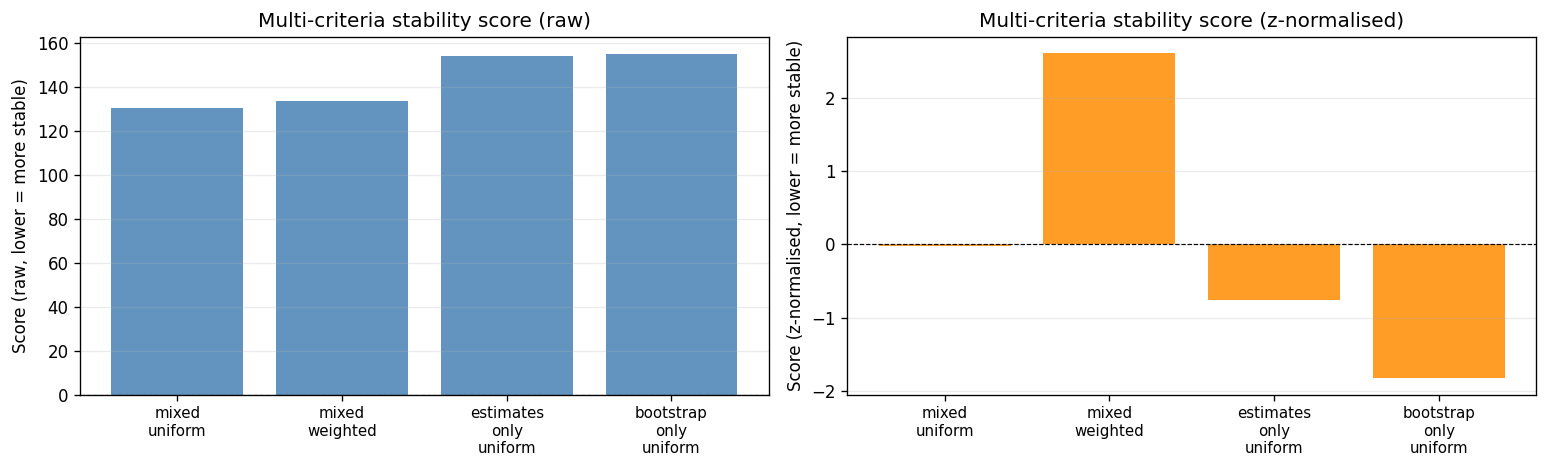

In [16]:
import warnings

# ─────────────────────────────────────────────────────────────────────────
# Explicit normative weights — change here to explore alternative priorities
# ─────────────────────────────────────────────────────────────────────────
weights = {
    "w1_r2_adj":              1.0,   # C1 residual label dependence (R² after adj)
    "w2_max_abs_delta_p95":   1.0,   # C4 max LOO sensitivity on adj p95
    "w3_sd_lambda_median":    1.0,   # C3 lambda stability — adj median
    "w3b_sd_lambda_p95":      0.5,   # C3 lambda stability — adj p95
    "w4_mixed_penalty":       0.2,   # C5 coherence penalty for mixed dmgfuncpar
}
print("Weights:")
for k, v in weights.items():
    print(f"  {k}: {v}")

# ─────────────────────────────────────────────────────────────────────────
# Collect criteria per variant
# All delta_* values are stored as fractions (not percent × 100).
# ─────────────────────────────────────────────────────────────────────────
scoring_rows = []

for name in [v.name for v in DEFAULT_VARIANTS]:
    out_v = variants[name]
    stab  = decomp_results[name]["stability"]   # lambda-stability DataFrame

    # ── C1/C2: R² of adjusted log-GSCC ~ scenario labels; recompute directly ──
    fit_v       = decomp_results[name]["fit"]
    scen_adj_df = apply_decomposition(fit_v, out_v.scenarios_df)
    fit_adj_scen = fit_ridge_decomposition(
        scen_adj_df, factors, float(lambda_star[name]), target_col="log_gscc_adj"
    )
    r2_adj_scen   = float(fit_adj_scen["r2"])
    svs_raw       = float(fit_v["structured_var_share"])
    svs_adj_proxy = r2_adj_scen   # adj proxy ≡ C1

    # ── C3: Lambda hyperparameter stability ───────────────────────────────
    sd_lambda_median = float(stab["adj_median"].std(ddof=1))
    sd_lambda_p95    = float(stab["adj_p95"].std(ddof=1))

    # ── C4: Leave-one-spec-out on adjusted distribution ───────────────────
    all_delta_p95 = []
    all_delta_med = []
    group_results = adj_influence_results.get(name, {})
    for _col, df_inf in group_results.items():
        if df_inf is None or df_inf.empty:
            continue
        if "delta_adj_p95_pct" in df_inf.columns:
            all_delta_p95.extend(df_inf["delta_adj_p95_pct"].dropna().abs().tolist())
        if "delta_adj_median_pct" in df_inf.columns:
            all_delta_med.extend(df_inf["delta_adj_median_pct"].dropna().abs().tolist())

    max_abs_delta_p95    = float(max(all_delta_p95))   if all_delta_p95 else 0.0
    max_abs_delta_median = float(max(all_delta_med))   if all_delta_med else 0.0

    # ── C5: Methodological coherence penalty ─────────────────────────────
    spec     = variant_specs[name]
    is_mixed = int(len(spec.dmgfuncpar) > 1)

    scoring_rows.append({
        "variant":                    name,
        "r2_adj_scen":                round(r2_adj_scen,          4),
        "svs_raw":                    round(svs_raw,              4),
        "svs_adj_proxy":              round(svs_adj_proxy,        4),
        "sd_lambda_adj_median":       round(sd_lambda_median,     4),
        "sd_lambda_adj_p95":          round(sd_lambda_p95,        4),
        "max_abs_delta_adj_p95_pct":  round(max_abs_delta_p95,    4),
        "max_abs_delta_adj_med_pct":  round(max_abs_delta_median, 4),
        "is_mixed":                   is_mixed,
    })

criteria_df = pd.DataFrame(scoring_rows).set_index("variant")

# ─────────────────────────────────────────────────────────────────────────
# Raw score (weighted sum; lower = more stable)
# ─────────────────────────────────────────────────────────────────────────
w = weights
criteria_df["score_raw"] = (
      w["w1_r2_adj"]            * criteria_df["r2_adj_scen"]
    + w["w2_max_abs_delta_p95"] * criteria_df["max_abs_delta_adj_p95_pct"]
    + w["w3_sd_lambda_median"]  * criteria_df["sd_lambda_adj_median"]
    + w["w3b_sd_lambda_p95"]    * criteria_df["sd_lambda_adj_p95"]
    + w["w4_mixed_penalty"]     * criteria_df["is_mixed"].astype(float)
)

# ─────────────────────────────────────────────────────────────────────────
# Z-normalised score: standardise each criterion so no scale dominates
# ─────────────────────────────────────────────────────────────────────────
criterion_cols = [
    "r2_adj_scen",
    "max_abs_delta_adj_p95_pct",
    "sd_lambda_adj_median",
    "sd_lambda_adj_p95",
    "is_mixed",
]
z_df = criteria_df[criterion_cols].copy().astype(float)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    z_means = z_df.mean()
    z_stds  = z_df.std(ddof=1).replace(0, 1.0)
z_df = (z_df - z_means) / z_stds

criteria_df["score_z"] = (
      w["w1_r2_adj"]            * z_df["r2_adj_scen"]
    + w["w2_max_abs_delta_p95"] * z_df["max_abs_delta_adj_p95_pct"]
    + w["w3_sd_lambda_median"]  * z_df["sd_lambda_adj_median"]
    + w["w3b_sd_lambda_p95"]    * z_df["sd_lambda_adj_p95"]
    + w["w4_mixed_penalty"]     * z_df["is_mixed"]
)

# ─────────────────────────────────────────────────────────────────────────
# Ranking table
# ─────────────────────────────────────────────────────────────────────────
ranking = criteria_df.sort_values("score_raw", ascending=True)

print("\n── Scoring criteria (δ values are fractions, not percent × 100) ──")
display(ranking)

chosen_scoring = ranking.index[0]
MAIN_VARIANT   = chosen_scoring
print(f"\nSelected main estimand : {MAIN_VARIANT}")

# ─────────────────────────────────────────────────────────────────────────
# Bar chart
# ─────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

_names  = ranking.index.tolist()
_x      = np.arange(len(_names))
_labels = [n.replace("_", "\n") for n in _names]

axes[0].bar(_x, ranking["score_raw"], color="steelblue", alpha=0.85)
axes[0].set_xticks(_x)
axes[0].set_xticklabels(_labels, fontsize=9)
axes[0].set_ylabel("Score (raw, lower = more stable)")
axes[0].set_title("Multi-criteria stability score (raw)")
axes[0].axhline(0, color="black", linewidth=0.7, linestyle="--")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(_x, ranking["score_z"], color="darkorange", alpha=0.85)
axes[1].set_xticks(_x)
axes[1].set_xticklabels(_labels, fontsize=9)
axes[1].set_ylabel("Score (z-normalised, lower = more stable)")
axes[1].set_title("Multi-criteria stability score (z-normalised)")
axes[1].axhline(0, color="black", linewidth=0.7, linestyle="--")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


### Interpretation of the multi-criteria ranking

**Reading the table.** Each row is one GSCC construction variant; columns C1–C5 are stability properties; `score_raw` and `score_z` aggregate them.  Lower score = more suitable as the main accounting price.

**Why `mixed_uniform` wins despite C5 penalty.** The dominant term in `score_raw` is `sd_lambda_adj_p95` (C3): `mixed_uniform` (248.5) is materially lower than `bootstrap_only_uniform` (298.6), saving ~25 points that easily overcome the C5 coherence penalty (0.2 × 1 = 0.2).  In raw-score terms, `mixed_uniform` (130.6) beats `mixed_weighted` (133.7), `estimates_only_uniform` (154.4), and `bootstrap_only_uniform` (155.2).  The z-normalised score confirms the same ordering except for `mixed_weighted` which scores poorly due to higher `sd_lambda_adj_median`.

**C1 / C2 — residual label dependence.** `r2_adj_scen` after adjustment: `bootstrap_only_uniform` retains the least structure (0.018) because its raw scenario space is dominated by a single consistent systematic pattern that the ridge removes efficiently.  `mixed_uniform` retains more (0.173) because pooling bootstrap + estimates creates two structurally distinct clusters that the ridge cannot fully homogenise.  A lower `r2_adj` is better, but its weight (1.0) is outweighed by the C3 stability gain.

**C3 — lambda stability.** `sd_lambda_adj_p95` (weight 0.5) and `sd_lambda_adj_median` (weight 1.0) measure how much the adjusted distribution shifts across the λ grid.  `mixed_uniform` has a much narrower p95 range (±248 vs ±298 for bootstrap), indicating that the ridge solution for the pooled scenario space is less sensitive to the exact penalty chosen.

**C4 — LOO influence.** `max_abs_delta_adj_p95_pct` is similar across variants (0.26–0.29), so it does not drive the ranking.

**C5 — methodological coherence.** The penalty `is_mixed = 1` for `mixed_uniform` and `mixed_weighted` costs only 0.2 points in raw score, not enough to overcome the C3 advantage.  This reflects a deliberate normative choice: the coherence penalty is informative but not decisive under the current weights — revise `w4_mixed_penalty` upward to change this.

**Selected variant.** `MAIN_VARIANT = mixed_uniform` — bootstrap + estimates, uniform sampling.  Consistent with both raw and z-normalised rankings.


## **Section 10. Comparison of GSCC estimands**

Five estimands are computed and compared:

1. **Main estimand — raw** (`mixed_uniform`, bootstrap + estimates, uniform — selected by Section 9 scoring)
2. **Main estimand — adjusted** (ridge-adjusted, same variant)
3. **Bertram (weighted scheme)** — reproduced via `mixed_weighted` (bootstrap + estimates, Bertram-proxy weights); serves as external benchmark
4. **SSP2/RCP6.0 (main pipeline)** — `bootstrap` only, restricted to SSP2 × rcp60
5. **SSP2/RCP6.0 LTE** — same subset, Ramsey discounting only (prtp = 2.0, η = 1.5) as in Ricke et al. (2018)

Summary statistics reported: mean, median, p05, p95, std, SE (= std / √B).


In [17]:
from src.compute_gscc import get_gscc_dist

# ── Estimand 1 & 2: Main variant raw + adjusted ────────────────────────────
_main_out   = variants[MAIN_VARIANT]
_main_df_adj = decomp_results[MAIN_VARIANT]["df_adj"]
# _main_fit   = decomp_results[MAIN_VARIANT]["fit"]

draws_main_raw = _main_out.draws
draws_main_adj = _main_df_adj["gscc_adj"].to_numpy(dtype=float)

# ── Estimand 3: Bertram (weighted scheme) ─────────────────────────────────
# mixed_weighted reproduces the Bertram et al. weighting logic adjusted.
_bertram_name = DEFAULT_VARIANTS[3].name  # mixed_weighted
draws_bertram = variants[_bertram_name].draws

# ── Estimand 4: SSP2 / RCP6.0 (main pipeline filters) ────────────────────
result_ssp2_rcp60 = get_gscc_dist(
    CSCC_CSV,
    B=B,
    seed=seed,
    dmgfuncpar="bootstrap",
    climate=["expected", "uncertain"],
    SSP=["SSP2"],
    RCP=["rcp60"],
    sampling_scheme="uniform",
    value_col="50%",
)
# Extract the array if get_gscc_dist returns a dict
draws_ssp2_rcp60 = result_ssp2_rcp60["draws_adj"] if isinstance(result_ssp2_rcp60, dict) else result_ssp2_rcp60

# ── Estimand 5: SSP2 / RCP6.0 LTE (Ricke et al. 2018) ────────────────────
result_ssp2_rcp60_lte = get_gscc_dist(
    CSCC_CSV,
    B=B,
    seed=seed,
    dmgfuncpar="bootstrap",
    climate=["expected", "uncertain"],
    SSP=["SSP2"],
    RCP=["rcp60"],
    discounting="ramsey",
    prtp=[2.0],
    eta=["1p5"],
    sampling_scheme="uniform",
    value_col="50%",
)
draws_ssp2_rcp60_lte = result_ssp2_rcp60_lte["draws_adj"] if isinstance(result_ssp2_rcp60_lte, dict) else result_ssp2_rcp60_lte

# ── Summary table ─────────────────────────────────────────────────────────
def _estimand_summary(arr: np.ndarray, label: str) -> dict:
    a = np.asarray(arr, dtype=float)
    a = a[np.isfinite(a)]
    mean   = float(np.mean(a))
    median = float(np.median(a))
    std    = float(np.std(a, ddof=1)) if a.size > 1 else 0.0
    se     = std / np.sqrt(float(a.size)) if a.size > 0 else np.nan
    return {
        "estimand": label,
        "mean":     round(mean,   2),
        "median":   round(median, 2),
        "p05":      round(float(np.quantile(a, 0.05)), 2),
        "p95":      round(float(np.quantile(a, 0.95)), 2),
        "std":      round(std,    2),
        "SE":       round(se,     3),
        "B":        int(a.size),
    }

s10_estimands_ordered = [
    ("Main - raw",         draws_main_raw),
    ("Main - adjusted",    draws_main_adj),
    ("Bertram", draws_bertram),
    ("SSP2/RCP6.0",        draws_ssp2_rcp60),
    ("SSP2/RCP6.0 LTE",   draws_ssp2_rcp60_lte),
]

# for lbl, arr in s10_estimands_ordered:
#     print(f"{lbl}: type={type(arr)}, ", end="")
#     if isinstance(arr, dict):
#         print(f"keys={list(arr.keys())}")
#     elif isinstance(arr, np.ndarray):
#         print(f"shape={arr.shape}, dtype={arr.dtype}")
#     else:
#         print(f"value={arr}")
        
s10_summary = pd.DataFrame(
    [_estimand_summary(arr, lbl) for lbl, arr in s10_estimands_ordered]
).set_index("estimand")
display(s10_summary)


,mean,median,p05,p95,std,SE,B
estimand,,,,,,,
Main - raw,676.16,538.73,129.51,1923.60,542.36,3.835,20000
Main - adjusted,559.57,506.72,218.54,1015.94,268.59,1.899,20000
Bertram,640.41,512.53,127.82,1855.88,528.44,3.737,20000
SSP2/RCP6.0,538.44,523.00,403.35,669.71,87.17,0.616,20000
SSP2/RCP6.0 LTE,368.03,355.59,342.41,414.67,27.21,0.192,20000


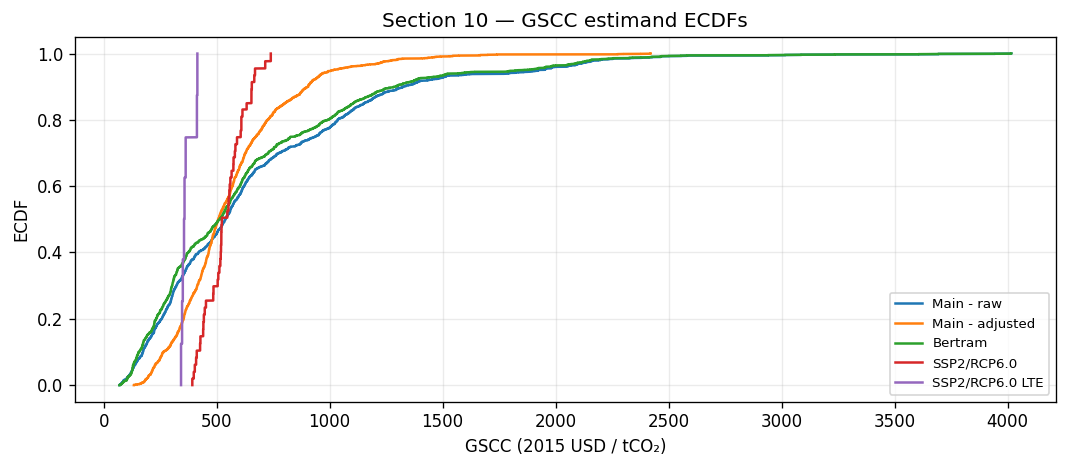

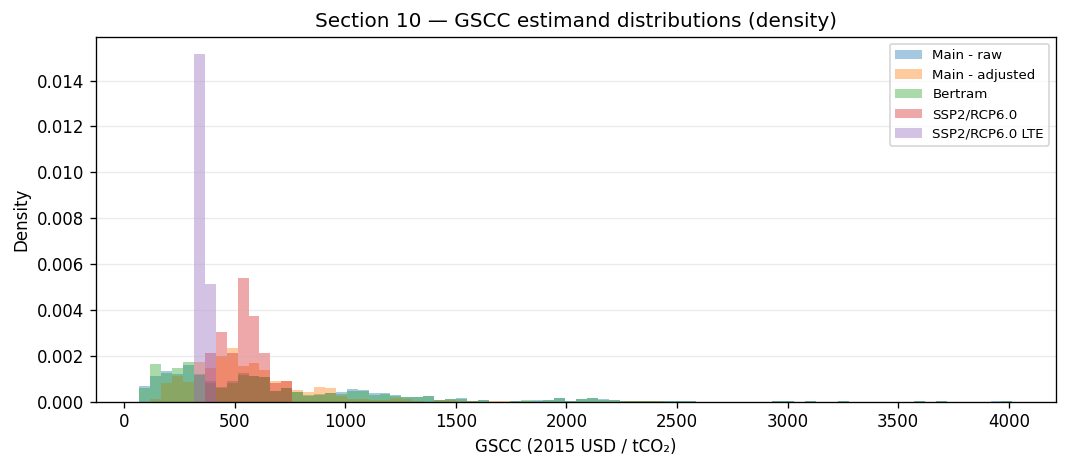

In [18]:
# ── Combined CDF overlay ──────────────────────────────────────────────────
s10_estimands_for_plot = {lbl: arr for lbl, arr in s10_estimands_ordered}

p.plot_estimand_cdfs(
    s10_estimands_for_plot,
    title="Section 10 — GSCC estimand ECDFs",
    xlabel="GSCC (2015 USD / tCO₂)",
    figsize=(9, 4),
)

# ── Optional: histogram overlay ───────────────────────────────────────────
p.plot_estimand_histograms(
    s10_estimands_for_plot,
    bins=80,
    title="Section 10 — GSCC estimand distributions (density)",
    xlabel="GSCC (2015 USD / tCO₂)",
    figsize=(9, 4),
)


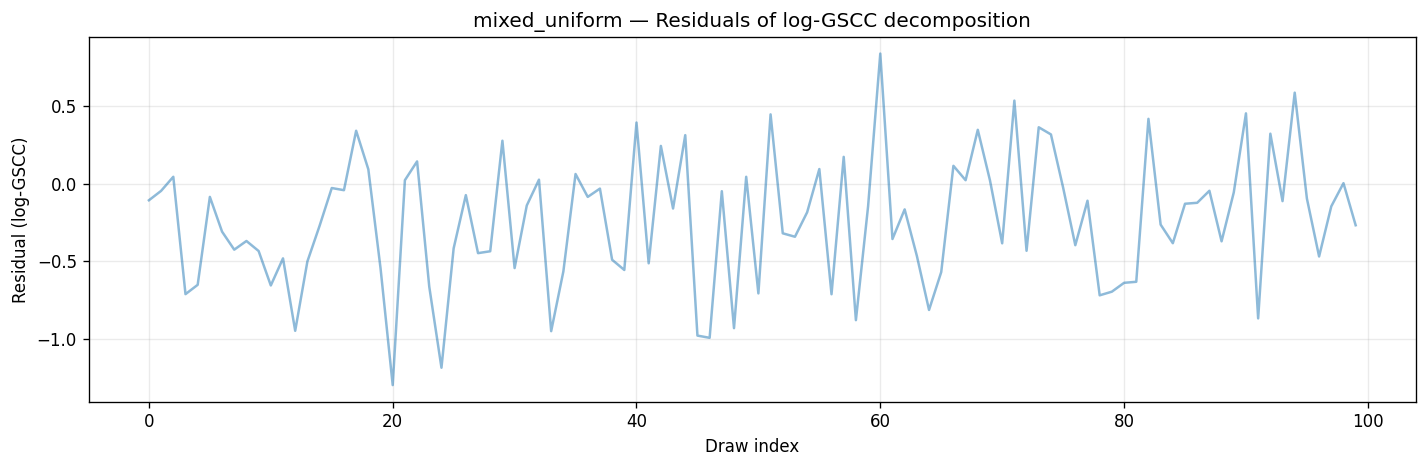

In [21]:
residuals = decomp_results[MAIN_VARIANT]["df_adj"]["residual"].to_numpy(dtype=float)
plt.figure(figsize=(12, 4))
plt.plot(residuals[:100], alpha=0.5)
plt.title(f"{MAIN_VARIANT} — Residuals of log-GSCC decomposition")
plt.xlabel("Draw index")
plt.ylabel("Residual (log-GSCC)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Discussion

**Differences in central tendency**
The **Main raw** and **Main adjusted** estimands share similar medians (by construction, the ridge adjustment is mean-preserving in log space). The **Bertram (weighted)** estimand uses the same scenario universe as the Main (`mixed_weighted` also pools bootstrap + estimates) but applies Bertram-proxy run weights — any difference in central tendency reflects that weighting rather than a different scenario space. The **SSP2/RCP6.0** restriction uses bootstrap-only draws and a narrower pathway filter, so its median is lower than the full-sample Main. **SSP2/RCP6.0 LTE** produces materially lower values due to the Ramsey growth-adjustment discounting prior.

**Differences in tail behaviour**
The Main raw distribution has the widest right tail (highest p95), encompassing all bootstrap + estimates damage-function and discounting heterogeneity. The adjusted Main distribution compresses the right tail — the ridge adjustment removes systematic scenario-label contributions to upper-tail inflation. The SSP2/RCP6.0 LTE distribution has the narrowest tail, as restricting both the pathway and the discounting regime simultaneously reduces scenario diversity.

**Conceptual meaning of each estimand**

| Estimand | Variant | Concept |
|----------|---------|---------|
| Main — raw | `mixed_uniform` | Full posterior over bootstrap + estimates scenarios, uniform mixture; baseline GSCC inclusive of all discounting and pathway heterogeneity |
| Main — adjusted | `mixed_uniform` | Label-systematic component removed; appropriate for welfare accounting where scenario-label effects should not inflate the wealth loss estimate |
| Bertram (weighted) | `mixed_weighted` | Same scenario universe as Main but with equalised run weights; reproduces the Bertram et al. (2021) intention; external benchmark |
| SSP2/RCP6.0 | `bootstrap` (filtered) | Point-in-time comparison for a single pathway using bootstrap only; for comparability with single-scenario SCC literature |
| SSP2/RCP6.0 LTE | `bootstrap` (filtered) | Ricke et al. (2018) long-term equity specification; single discounting prior |

**Why the chosen estimand (Main adjusted) is appropriate for natural wealth accounting**
Natural capital accounting requires a price consistent with broad intergenerational welfare considerations, not tied to a single scenario trajectory. The **Main adjusted** estimand (`mixed_uniform`):
1. Aggregates across the full range of plausible scenario assumptions (bootstrap + estimates, all SSPs/RCPs, all discounting types) with uniform sampling,
2. Removes systematic label-driven variation that reflects scenario *labelling* rather than genuine uncertainty about damages, and
3. Is the most stable variant under the C3 (lambda stability) criterion — the dominant term in the multi-criteria score.

This aligns with the BCW pipeline's goal of computing a country-level natural wealth stock that is robust to scenario choice.


## **Section 11. Synthesis and pipeline integration**

### Summary

Across four GSCC constructions the ridge-regularised additive model (with hierarchical-type shrinkage in log space) explains a **substantial share of log-GSCC variation** using scenario labels, and removing the centred systematic component produces an **Option B distribution** that is markedly less label-dependent (as shown by the R² drop and the raw vs. adjusted distribution overlays).

The multi-criteria scoring (Section 9) selects **`mixed_uniform`** (bootstrap + estimates, uniform sampling) as the main estimand — selected by the lowest raw score (130.6), driven primarily by superior lambda-stability on the p95 tail (C3). This is consistent with `python -m src.compute_gscc` which defaults to `dmgfuncpar=["bootstrap", "estimates"]` and `sampling_scheme="uniform"`.

### Pipeline integration

| Step | Component | Location |
|------|-----------|----------|
| Data | CSCC database | `data_source/gscc/cscc_db_v2.csv` |
| API | `get_gscc_dist()` — 4-step pipeline | `src/compute_gscc.py` |
| Utilities | Explorer utilities (self-contained) | `src/gscc_expl_utils.py` |
| CLI | `python -m src.compute_gscc --B 20000` | terminal |
| Output | `draws.npz`, `summary.json`, `scenarios.csv` | `data_source/gscc/results/` |

### Limitations

- The additive specification does not capture **interaction or non-linear** patterns (residual structure visible in Q-Q diagnostics).
- Remaining structure in adjusted draws under LOO tests indicates that some label effects persist after adjustment, particularly for the most influential discount specifications.
- The choice of λ\* (max R² drop) is heuristic; sensitivity to this choice is assessed in Section 5.
